**Progetto corso di Applicazioni informatiche al Machine Learning anno 2024/2025**

Progetto scelto: "Textual Entailment" (Progetto 1)

Componenti del gruppo "The Empire": Giacomo Gatto, Giacomo El Sayed, Niccolò Pecorari, Ignazio Sagheddu

**Textual Entailment**, o Inferenza in Linguaggio Naturale (NLI), è uno dei compiti fondamentali e più affascinanti del Natural Language Processing (NLP). L'obiettivo è insegnare a una macchina a "ragionare" sulla relazione logica tra due frasi: una premessa e un'ipotesi. Il modello deve determinare se l'ipotesi è un'implicazione logica della premessa, una contraddizione o se è semanticamente neutrale.

Questo progetto affronta tale sfida utilizzando il celebre dataset SNLI (Stanford Natural Language Inference), un benchmark di riferimento per questo task. Per risolvere il problema, abbiamo adottato una strategia comparativa, implementando e valutando due modelli con approcci radicalmente diversi:

**Modello Baseline** - TF-IDF e Regressione Logistica: Come primo passo, abbiamo costruito un modello basato su tecniche classiche di NLP. Le frasi vengono trasformate in vettori numerici utilizzando la metrica TF-IDF, che pesa l'importanza delle parole. Questi vettori alimentano poi un modello di Regressione Logistica.

**Modello Avanzato** - LSTM e Word Embeddings GloVe: successivamente, abbiamo sviluppato un'architettura basata su deep learning. Questo modello utilizza una rete neurale ricorrente LSTM (Long Short-Term Memory), progettata per interpretare il significato sequenziale e contestuale delle frasi. Per catturare le ricche relazioni semantiche tra le parole, il modello sfrutta la conoscenza pre-addestrata dei word embeddings GloVe. Questa architettura è intrinsecamente più potente e mira a ottenere una comprensione più profonda del linguaggio.

Attraverso questo doppio approccio, il progetto non si limita a costruire un classificatore, ma conduce un'analisi comparativa per valutare il salto prestazionale offerto dalle reti neurali ricorrenti rispetto ai metodi tradizionali.

Caratteristiche principali del dataset:

Dimensione: Contiene circa 570.000 coppie di frasi (premessa-ipotesi) scritte in inglese.

Origine: Le frasi sono state create a partire da didascalie di immagini. Questo approccio garantisce una grande varietà linguistica e un'alta qualità delle annotazioni, poiché i volontari dovevano descrivere la stessa scena in modi diversi.

Struttura: Ogni elemento del dataset è una tupla contenente:

Una frase premessa (es. "A man is cooking in his kitchen").
Una frase ipotesi (es. "A person is preparing food").
Un'etichetta di relazione logica (entailment, contradiction o neutral).

*Cella 1 e 2**: Importazione dei moduli utili al caricamento del dataset

Iniziamo importando i moduli che ci saranno utili in questa fase iniziale. Il modulo "requests" ci è utile per il download del dataset, in quanto ci permette di inviare richieste http ritornando un response object con tutti i response data. Il modulo "zipfile" è essenziale per la creazione, lettura e modifica di archivi zip. Grazie a questo modulo estraiamo il contenuto della zip scaricata dall'url "https://nlp.stanford.edu/projects/snli/snli_1.0.zip". Il modulo "os" è utile per esplorare le directory di interesse e, nel nostro caso, lo utilizziamo per verificare che l'archivio zip sia stato scaricato correttamente. Se la condizione viene soddisfatta (if not) la funzione downloadunzip_dataset(), precedentemente definita, viene eseguita nuovamente.

In [1]:
#=====================================
#  1. IMPORTAZIONE MODULI PER UPLOAD
#=====================================

import os
import requests
import zipfile

In [2]:
#===================================
#    2. IMPORTAZIONE DEL DATASET
#===================================

dataset_url = "https://nlp.stanford.edu/projects/snli/snli_1.0.zip"
zip_filename = "snli_1.0.zip"
extract_path = "snli_1.0"

def downloadunzip_dataset():
  response = requests.get(dataset_url)
  response.raise_for_status()
  with open(zip_filename, "wb") as zip_file:
    zip_file.write(response.content)

  with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall()

if not os.path.exists(zip_filename):
  try:
    downloadunzip_dataset()
    for item in os.listdir(extract_path):
      print("-", item)

  except Exception as e:
    print(f"Error downloading and extracting the dataset: {e}")


KeyboardInterrupt: 

In [ ]:
#=================================================
#  # 3. CARICAMENTO E PULIZIA DATAFRAME DA JSON
#=================================================

import pandas as pd
def load_and_clean_df(data_path):
    """
    Carica un DataFrame da un file .jsonl e rimuove le righe con etichetta '-'.
    """
    df = pd.read_json(data_path, lines=True)
    df = df[df['gold_label'] != '-'].reset_index(drop=True)
    return df

**Cella 4:Exploratory Data Analysis (EDA)**

Proseguiamo con l'analisi esplorativa del dataset, dove ci siamo posti tre domande:

-**Come sono distribuite le etichette?**

La funzione classes_distribution analizza la distribuzione delle tre etichette principali (entailment, neutral, contradiction) all'interno di ciascun set di dati (train, development e test). Creando un grafico a barre per ogni file, ci permette di verificare visivamente se il dataset è bilanciato, ovvero se ogni categoria è rappresentata in modo equo.

-**Qual è la lunghezza delle frasi?**

La funzione global_distributions esamina la lunghezza (calcolata come numero di parole) delle premesse (sentence1) e delle ipotesi (sentence2). Per ogni set di dati, genera due tipi di grafici:

Un grafico di densità (KDE) che mostra la distribuzione della lunghezza delle frasi, sovrapponendo le curve di premesse e ipotesi per un confronto diretto. Vengono inoltre tracciate le linee di media e mediana per avere un'idea della tendenza centrale.

Un boxplot che riassume la distribuzione della lunghezza, evidenziando la mediana, i quartili e la presenza di eventuali valori anomali (outliers).

Questa analisi ci aiuta a capire se ci sono differenze significative nella lunghezza tra premesse e ipotesi e a farci un'idea della complessità sintattica delle frasi.

-**Esiste una relazione tra la lunghezza delle frasi e l'etichetta?**

Infine, la funzione labels_lenghths_correlation approfondisce l'analisi, studiando se la distribuzione della lunghezza delle frasi cambia a seconda dell'etichetta associata. Analizzando il solo set di addestramento (essendo il più grande e rappresentativo), la funzione genera grafici di densità separati per ogni etichetta (entailment, neutral, contradiction). Questo ci permette di scoprire pattern interessanti, ad esempio se le frasi che si contraddicono tendono ad essere più lunghe o più corte di quelle che si implicano a vicenda.

La cella si conclude con la funzione principale EDA, che esegue tutte le analisi precedenti per fornire una panoramica visiva completa e dettagliata del nostro dataset.

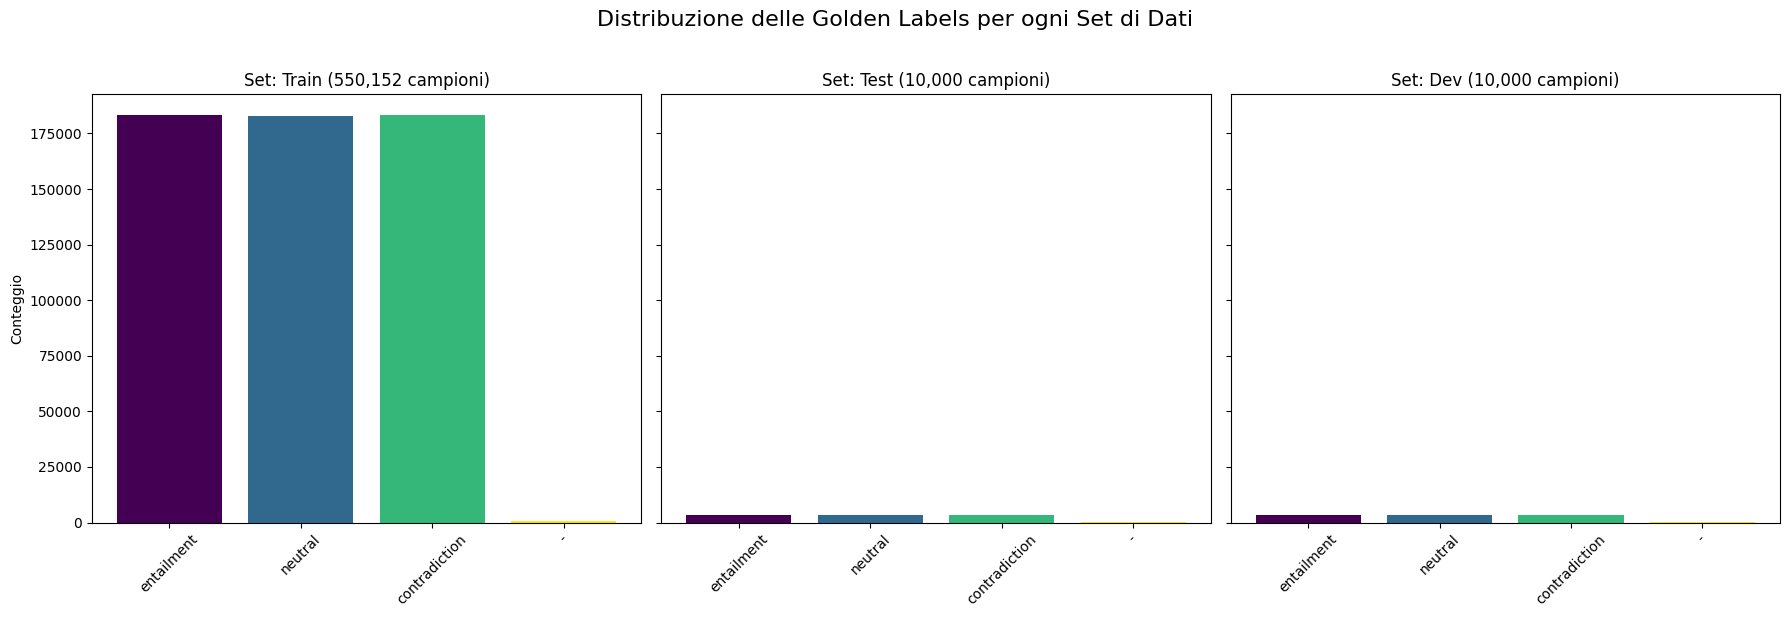

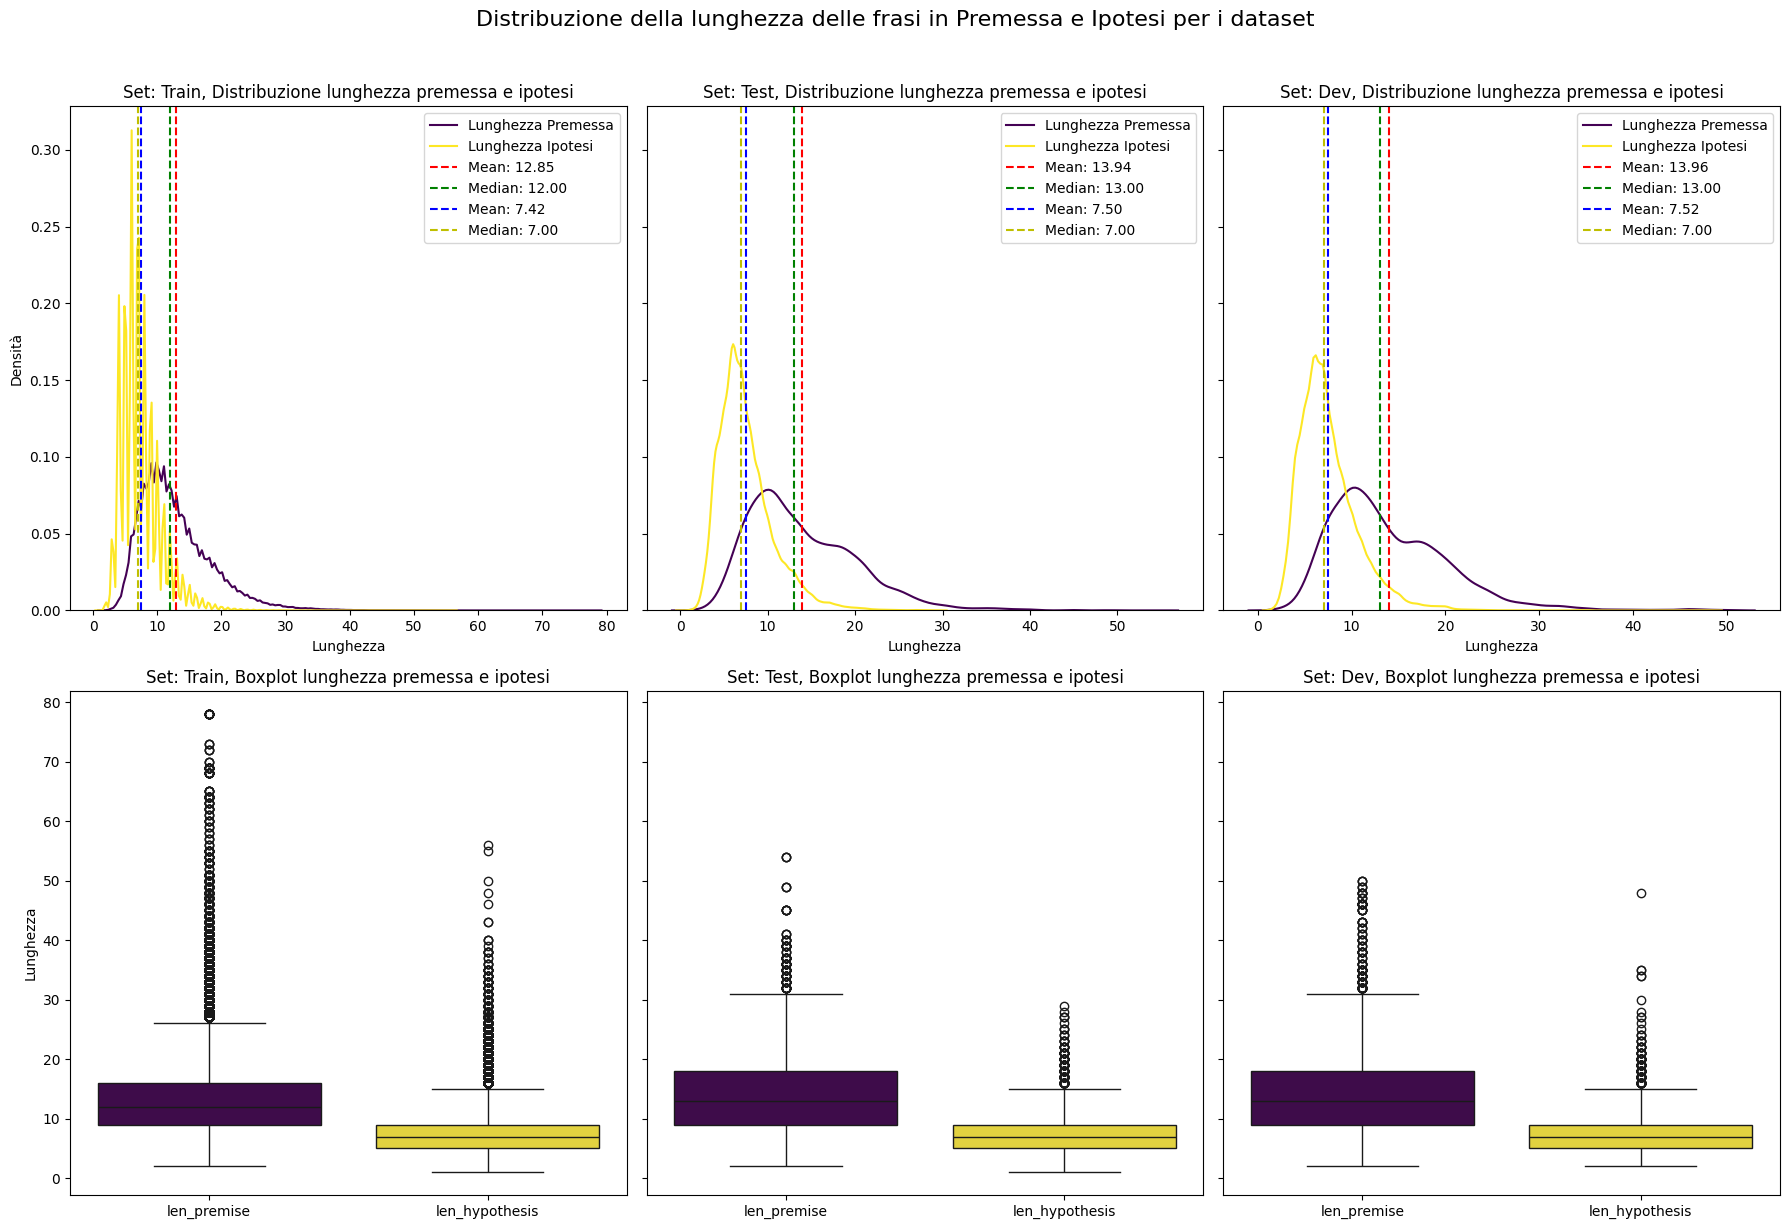

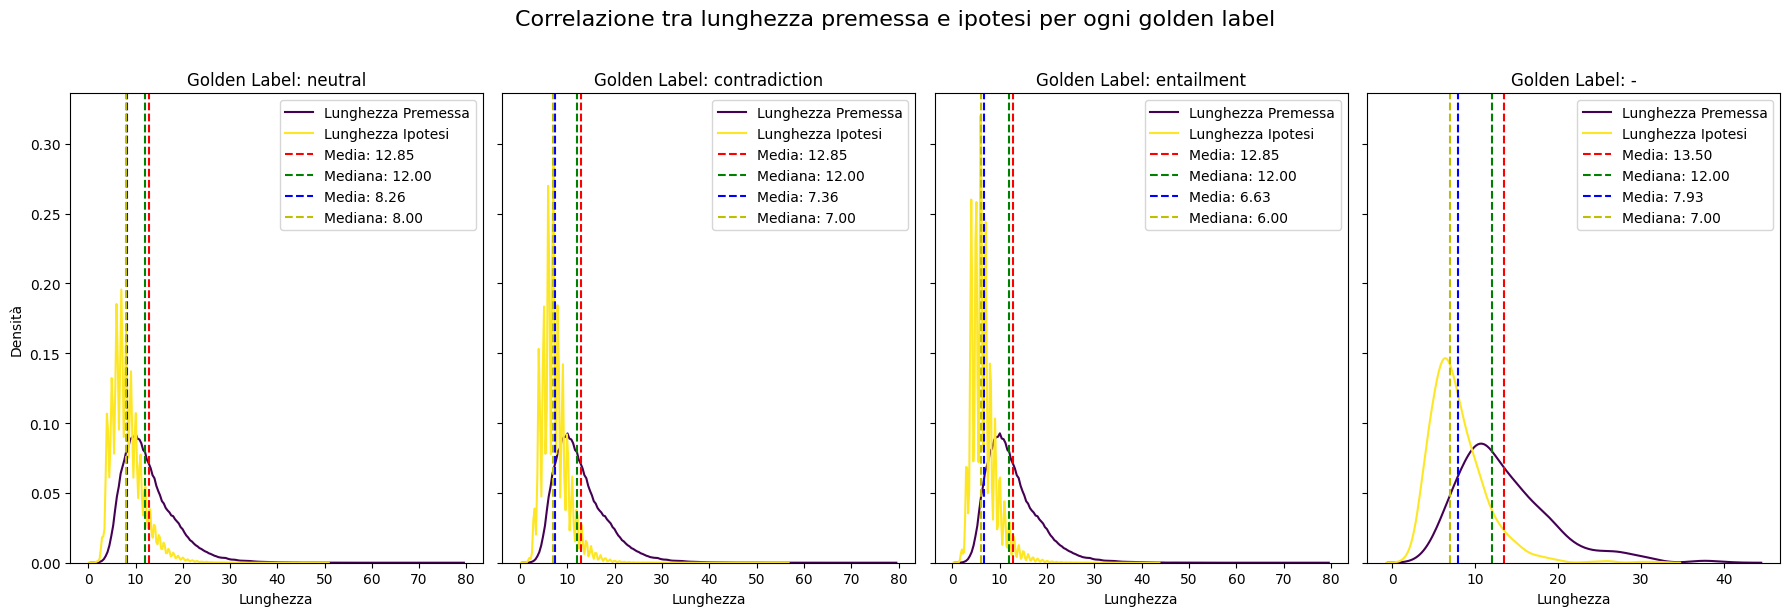

In [ ]:
#======================================
#  4. EXPLORATORY DATA ANALYSIS (EDA)
#======================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import os

# 4.1 Trasformazione da JSON a Dataframe
def json_to_df(data_path):
  df = pd.read_json(data_path, lines=True)
  return df

# 4.2 Definizione delle etichette di interesse mantenendo '-'
Golden_labels = ['entailment', 'neutral', 'contradiction', '-']

# 4.3 Grafico della distribuzione delle classi
def classes_distribution(data_directory):

  set_files = [f for f in os.listdir(data_directory) if f.endswith('.jsonl')]

  fig, axs = plt.subplots(nrows=1, ncols=len(set_files), figsize=(18, 6), sharey=True)
  fig.suptitle('Distribuzione delle Golden Labels per ogni Set di Dati', fontsize=16, y=1.02)

  for i, file_name in enumerate(set_files):

    df = json_to_df(os.path.join(data_directory, file_name))

    set_name = file_name.split('_')[-1].replace('.jsonl', '').capitalize()

    counts = df['gold_label'].value_counts()
    colors = plt.cm.viridis(np.linspace(0, 1, len(Golden_labels)))
    bars = axs[i].bar(Golden_labels, [counts.get(label, 0) for label in Golden_labels], color=colors)

    axs[i].set_title(f'Set: {set_name} ({len(df):,} campioni)')
    axs[i].set_xlabel('')
    axs[i].tick_params(axis='x', rotation=45)


  axs[0].set_ylabel('Conteggio')

  plt.tight_layout()
  plt.show()


def global_distributions(data_directory):
  # Per ogni dataset, plot distribuzione di len premessa e len ipotesi con due curve
  # e grafico con media e dev standard di len premmessa e len ipotesi con outliers
  set_files = [f for f in os.listdir(data_directory) if f.endswith('.jsonl')]
  fig, axs = plt.subplots(nrows=2, ncols=len(set_files), figsize=(18, 12), sharey='row')
  fig.suptitle('Distribuzione della lunghezza delle frasi in Premessa e Ipotesi per i dataset', fontsize=16, y=1.02)

  colors = plt.cm.viridis(np.linspace(0, 1, 2))

  for i, file_name in enumerate(set_files):
    df = json_to_df(os.path.join(data_directory, file_name))
    set_name = file_name.split('_')[-1].replace('.jsonl', '').capitalize()

    # Calcolo della lunghezza di 'sentence1' per 'premise' e 'sentence2' per 'hypothesis'
    df['len_premise'] = df['sentence1'].str.split().str.len()
    df['len_hypothesis'] = df['sentence2'].str.split().str.len()

    # distribuzione sovrapposta della lunghezza di 'premises' e 'hypothesis'
    sns.kdeplot(data=df, x='len_premise', ax=axs[0, i], label='Lunghezza Premessa', color=colors[0])
    sns.kdeplot(data=df, x='len_hypothesis', ax=axs[0, i], label='Lunghezza Ipotesi', color=colors[1])
    # distribuzione sovrapposta della media e della mediana della lunghezza di 'premises' e 'hypothesis'
    mean_p, mean_h = df['len_premise'].mean(), df['len_hypothesis'].mean()
    med_p, med_h = df['len_premise'].median(), df['len_hypothesis'].median()

    axs[0, i].axvline(mean_p, color='r', linestyle='--', label=f'Mean: {mean_p:.2f}')
    axs[0, i].axvline(med_p, color='g', linestyle='--', label=f'Median: {med_p:.2f}')
    axs[0, i].axvline(mean_h, color='b', linestyle='--', label=f'Mean: {mean_h:.2f}')
    axs[0, i].axvline(med_h, color='y', linestyle='--', label=f'Median: {med_h:.2f}')

    axs[0, i].legend()

    #Boxplot

    sns.boxplot(data=df[['len_premise', 'len_hypothesis']], ax=axs[1, i], palette=[colors[0], colors[1]])

    axs[0, i].set_title(f'Set: {set_name}, Distribuzione lunghezza premessa e ipotesi')
    axs[1, i].set_title(f'Set: {set_name}, Boxplot lunghezza premessa e ipotesi')

    axs[0, i].set_xlabel('Lunghezza')
    axs[0, i].set_ylabel('Densità')

    axs[1, i].set_xlabel('')
    axs[1, i].set_ylabel('Lunghezza')


  plt.tight_layout()
  plt.show()



def labels_lenghths_correlation(data_directory):

  df = json_to_df(os.path.join(data_directory, 'snli_1.0_train.jsonl'))
  g_lables = df['gold_label'].unique()
  colors = plt.cm.viridis(np.linspace(0, 1, 2))

  fig, axs = plt.subplots(nrows=1, ncols=len(g_lables), figsize=(18, 6), sharey=True)
  fig.suptitle('Correlazione tra lunghezza premessa e ipotesi per ogni golden label', fontsize=16, y=1.02)
  for lable in g_lables:
    df_filtered = df[df['gold_label'] == lable].copy()
    df_filtered['len_premise'] = df_filtered['sentence1'].str.split().str.len()
    df_filtered['len_hypothesis'] = df_filtered['sentence2'].str.split().str.len()
    sns.kdeplot(data=df_filtered, x='len_premise', ax=axs[g_lables.tolist().index(lable)], label='Lunghezza Premessa', color=colors[0])
    sns.kdeplot(data=df_filtered, x='len_hypothesis', ax=axs[g_lables.tolist().index(lable)], label='Lunghezza Ipotesi', color=colors[1])

    mean_p, mean_h = df_filtered['len_premise'].mean(), df_filtered['len_hypothesis'].mean()
    med_p, med_h = df_filtered['len_premise'].median(), df_filtered['len_hypothesis'].median()

    axs[g_lables.tolist().index(lable)].axvline(mean_p, color='r', linestyle='--', label=f'Media: {mean_p:.2f}')
    axs[g_lables.tolist().index(lable)].axvline(med_p, color='g', linestyle='--', label=f'Mediana: {med_p:.2f}')
    axs[g_lables.tolist().index(lable)].axvline(mean_h, color='b', linestyle='--', label=f'Media: {mean_h:.2f}')
    axs[g_lables.tolist().index(lable)].axvline(med_h, color='y', linestyle='--', label=f'Mediana: {med_h:.2f}')


    axs[g_lables.tolist().index(lable)].legend()
    axs[g_lables.tolist().index(lable)].set_title(f'Golden Label: {lable}')
    axs[g_lables.tolist().index(lable)].set_xlabel('Lunghezza')
    axs[g_lables.tolist().index(lable)].set_ylabel('Densità')


  plt.tight_layout()
  plt.show()


# Funzione principale per l'EDA
def EDA(data_directory):

  # Calcola il numero di set di dati direttamente dai file .jsonl trovati
  set_files = [f for f in os.listdir(data_directory) if f.endswith('.jsonl')]
  number_of_sets = len(set_files)

  #Call delle funzioni di plot
  if number_of_sets > 0:
    classes_distribution(data_directory)
    global_distributions(data_directory)
    labels_lenghths_correlation(data_directory)
  else:
    print(f"Nessun file .jsonl trovato in '{data_directory}'")

EDA(extract_path)

Di seguito, commentiamo i principali insights emersi dai grafici.

**Distribuzione delle Classi**

Il primo gruppo di grafici mostra la distribuzione delle etichette (entailment, neutral, contradiction) per i set di training, validazione (dev) e test.

 L'osservazione più importante è che il dataset è estremamente bilanciato. In ogni split, le tre classi principali sono rappresentate in numero quasi identico. Questo è uno scenario ideale per un problema di classificazione. Significa che non dovremo preoccuparci di bias del modello verso la classe maggioritaria. Possiamo utilizzare l'accuracy come metrica di valutazione affidabile.

**Analisi della Lunghezza delle Frasi**

Il secondo set di grafici (KDE e Boxplot) analizza la lunghezza, in numero di parole, delle premesse e delle ipotesi.

Emergono due pattern consistenti in tutti i set di dati:

Le premesse sono mediamente più lunghe delle ipotesi. Questo è visibile sia dal picco delle curve di densità sia dalla posizione della mediana nei boxplot.

Entrambe le distribuzioni sono asimmetriche a destra (right-skewed), con una lunga coda di frasi molto lunghe, come confermato dai numerosi outlier nei boxplot.

  La coerenza tra i set di training, validazione e test è un'ottima notizia, poiché suggerisce che il modello apprenderà su dati distribuiti in modo simile a quelli su cui verrà valutato. La presenza di frasi molto lunghe ci suggerisce di pensare a una lunghezza massima di sequenza (max_length) durante la fase di tokenizzazione per gestire la memoria e la velocità di calcolo in modo efficiente.

**Relazione tra Lunghezza ed Etichetta**

L'ultimo gruppo di grafici esplora se la lunghezza delle frasi varia a seconda dell'etichetta di classificazione.

Le distribuzioni della lunghezza delle frasi sono praticamente identiche per tutte e tre le etichette. Non sembra esserci una correlazione evidente tra la lunghezza di una premessa o di un'ipotesi e la loro relazione logica. Questo dato ci suggerisce che il modello non potrà basarsi su semplici euristiche (come "se l'ipotesi è molto più corta della premessa, allora è un'implicazione") per risolvere il task. La soluzione del problema risiede interamente nella comprensione delle relazioni semantiche e logiche tra le parole e le frasi, non in caratteristiche strutturali.

L'EDA ci conferma che SNLI è un dataset di alta qualità, ben bilanciato e strutturato. La sfida sarà puramente semantica, il che lo rende perfetto per testare le capacità di modelli di linguaggio avanzati.

**Cella 5: Preparazione dei Dati per il Modello**

Dopo aver esplorato il dataset, è il momento di prepararlo per darlo in pasto al nostro modello di machine learning.

Il blocco di codice successivo esegue tre operazioni che trasformano dati in un formato digeribile dal modello:

-**Caricamento e Pulizia Definitiva**

Anche se lo abbiamo già fatto per l'EDA, ricarichiamo i dati utilizzando la funzione load_and_clean_df. Questo assicura di partire da una base pulita, rimuovendo nuovamente tutte le righe la cui etichetta è '-', che non sono utili per il nostro task di classificazione a tre vie (entailment, neutral, contradiction).

-**Codifica Numerica delle Etichette (Label Encoding)**

I modelli di machine learning richiedono input numerici. Le nostre etichette (gold_label) sono stringhe di testo, quindi dobbiamo convertirle in numeri. Per fare ciò, utilizziamo LabelEncoder di Scikit-learn.

Applicando fit_transform sul training set l'encoder sviluppa la mappatura tra le etichette testuali e i numeri (es. entailment -> 0, neutral -> 1, contradiction -> 2) e applica questa trasformazione. Successivamente usiamo lo stesso encoder già per trasformare gli altri due set. Questo garantisce che la stessa mappatura venga mantenuta in modo coerente su tutti i dati.

-**Creazione della Feature di Input**

Per risolvere il task di Textual Entailment, il modello deve analizzare la relazione tra la premessa e l'ipotesi. Un approccio comune è quello di fornire entrambe le frasi come un unico input.
Per questo motivo, creiamo una nuova colonna chiamata combined_text. Questa colonna contiene semplicemente la concatenazione della premessa (sentence1) e dell'ipotesi (sentence2), separate da uno spazio. Sarà questa stringa combinata il nostro input che il modello utilizzerà per fare le sue previsioni.

Al termine di questa cella, i nostri DataFrame sono pronti: contengono il testo di input combinato e le etichette numeriche.


In [ ]:
#==========================================================================================
#  # 5. CARICAMENTO,PULIZIA E CREAZIONE FEATURE DI COMBINAZIONE DELLE FRASI DEI TRE DATASET
#==========================================================================================

from sklearn.preprocessing import LabelEncoder

# 5.1 Carica e pulisci i tre set di dati
df_train = load_and_clean_df(os.path.join(extract_path, 'snli_1.0_train.jsonl'))
df_val = load_and_clean_df(os.path.join(extract_path, 'snli_1.0_dev.jsonl'))
df_test = load_and_clean_df(os.path.join(extract_path, 'snli_1.0_test.jsonl'))

# 8.2 Codifica numericamente le label
label_encoder = LabelEncoder()
df_train['gold_label_encoded'] = label_encoder.fit_transform(df_train['gold_label'])
df_val['gold_label_encoded'] = label_encoder.transform(df_val['gold_label'])
df_test['gold_label_encoded'] = label_encoder.transform(df_test['gold_label'])

# 5.2 Combinazione delle frasi
df_train['combined_text'] = df_train['sentence1'].fillna('') + ' ' + df_train['sentence2'].fillna('')
df_val['combined_text'] = df_val['sentence1'].fillna('') + ' ' + df_val['sentence2'].fillna('')
df_test['combined_text'] = df_test['sentence1'].fillna('') + ' ' + df_test['sentence2'].fillna('')

print("Caricamento, pulizia e combinazione delle frasi completati.")

Caricamento, pulizia e combinazione delle frasi completati.


**Cella 6: Preprocessing per TF-IDF e Regressione Logistica**

Come modello baseline utilizzeremo una Regressione Logistica abbinata ad una rappresentazione testuale TF-IDF.

Il codice in questa cella si occupa di trasformare il nostro testo grezzo in un formato numerico che questi modelli possano interpretare, attraverso un processo di pulizia e vettorizzazione.

**Pulizia e Normalizzazione del Testo**

La funzione preprocess_corpus si occupa di "normalizzare" il testo, rendendolo più pulito e uniforme. Il processo inizia scaricando le risorse necessarie dalla libreria NLTK (Natural Language Toolkit), come la lista delle stop words e i componenti per l'analisi grammaticale.

Per ogni frase, la funzione esegue una serie di passaggi sequenziali. Prima di tutto, pulisce il testo rimuovendo ogni carattere che non sia una lettera e convertendo tutto in minuscolo. Questo assicura che parole come "Cane" e "cane" vengano trattate come la stessa entità. Successivamente, il testo viene suddiviso in singole parole (un processo chiamato tokenizzazione) e le stop words – parole molto comuni ma poco informative come "the", "a", "is" – vengono eliminate.

Il passo finale è la lemmatizzazione, che riduce le parole alla loro forma base o "lemma" (es. "running" e "ran" diventano "run"). Per farlo in modo accurato, il codice prima identifica la parte del discorso (verbo, nome, aggettivo, etc.) di ogni parola e poi applica la lemmatizzazione corretta. Questo processo riduce la dimensionalità del vocabolario e aiuta il modello a generalizzare meglio, concentrandosi sul significato intrinseco delle parole.

**Vettorizzazione con TF-IDF**

Una volta che il nostro corpus di frasi è stato ripulito e lemmatizzato, dobbiamo convertirlo in vettori numerici. Qui entra in gioco TF-IDF (Term Frequency-Inverse Document Frequency). Questo metodo non si limita a contare quante volte una parola appare in una frase, ma ne pesa l'importanza. Una parola ottiene un punteggio alto se appare frequentemente in un documento specifico (TF) ma raramente nell'intero corpus di documenti (IDF), rendendola un buon indicatore del contenuto di quella frase.

La cella definisce due funzioni per gestire questo processo. La funzione fit_vectorizer viene utilizzata esclusivamente sul set di addestramento. Impara il vocabolario del corpus di training e calcola i pesi IDF per ogni parola, creando una matrice numerica in cui ogni riga rappresenta una frase e ogni colonna una parola del vocabolario. La seconda funzione, transform_corpus, applica la trasformazione imparata dal vectorizer ai set di validazione e test, assicurando che tutti i dati siano processati in modo coerente e con lo stesso vocabolario.


In [ ]:
#=======================================================
#   6. PREPROCESSING PER TF-IDF + LOGISTIC REGRESSION
#                     Approccio (1)
#=======================================================

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import TfidfVectorizer
import re

nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    """Map NLTK POS tags to WordNet tags"""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# 6.1 Funzione di Pulizia del Testo
def preprocess_corpus(text_corpus_list):

    lemmatized_corpus = [] # Corpus lemmatizzato

    # Pulizia e tokenizzazione
    for elem in text_corpus_list:

        clean_text = re.sub(r'[^a-zA-Z\s]', '', elem).lower() # Rimozione caratteri non alfabetici e converte in minuscolo

        tokens = clean_text.split()  # Tokenizzazione (split per creare una lista di parole)

        filtered_tokens = [word for word in tokens if word not in stop_words] # Rimozione delle stop words

        pos_tags = nltk.pos_tag(filtered_tokens) #POS tagging
        lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags] #Lemmatizzazione

        lemmatized_document = ' '.join(lemmatized_words) #Ricostruzione del documento
        lemmatized_corpus.append(lemmatized_document)

    return lemmatized_corpus

# 6.2 Funzione di addestramento di TfidfVectorizer, restituisce il vectorizer e la matrice TF-IDF
def fit_vectorizer(train_corpus, ngram):

    vectorizer = TfidfVectorizer(ngram_range = (ngram, ngram))
    train_matrix = vectorizer.fit_transform(train_corpus)
    return vectorizer, train_matrix

# 6.3 Funzione che applica il TfidfVectorizer addestrato a un nuovo corpus
def transform_corpus(vectorizer, corpus):

    return vectorizer.transform(corpus)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


**Cella 7: Analisi del Vocabolario: Parole più Comuni **

Dopo aver analizzato nell'EDA le caratteristiche strutturali come la lunghezza delle frasi, vogliamo capire se ci sono termini specifici che compaiono più frequentemente a seconda che la relazione sia di implicazione, contraddizione o neutrale. Questa analisi può rivelare euristiche o bias nel dataset che un modello potrebbe imparare.

La funzione plot_top_words_premise_vs_hypothesis è progettata per condurre proprio questa indagine in modo granulare. Invece di guardare il vocabolario nel suo complesso, lo suddivide secondo due assi:

La relazione logica: entailment, neutral, contradiction.

Il tipo di frase: Premessa (sentence1) e Ipotesi (sentence2).

Per ogni combinazione (es. le premesse delle frasi in contraddiction), la funzione esegue una serie di passaggi. Innanzitutto, applica la stessa identica funzione di preprocessing (preprocess_corpus) che abbiamo usato per il modello TF-IDF. Questo garantisce coerenza e ci permette di analizzare le parole nella loro forma base (lemma), dopo aver rimosso le stop words. Successivamente, conta la frequenza di ogni parola e identifica le 10 più comuni.

Il risultato è una visualizzazione chiara e comparativa: una griglia di sei istogrammi. Le righe separano le premesse dalle ipotesi, mentre le colonne separano le tre etichette. Questo ci permette di confrontare a colpo d'occhio, ad esempio, se le parole più usate nelle ipotesi che portano a una contraddizione sono diverse da quelle che portano a un'implicazione. L'analisi ci aiuterà a capire se il task può essere risolto (anche solo parzialmente) riconoscendo la presenza di specifiche parole "chiave".

/tmp/ipython-input-2548906730.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequenza', y='Parola', data=top_df, ax=ax, palette='plasma')
/tmp/ipython-input-2548906730.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequenza', y='Parola', data=top_df, ax=ax, palette='plasma')
/tmp/ipython-input-2548906730.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequenza', y='Parola', data=top_df, ax=ax, palette='plasma')
/tmp/ipython-input-2548906730.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is depr

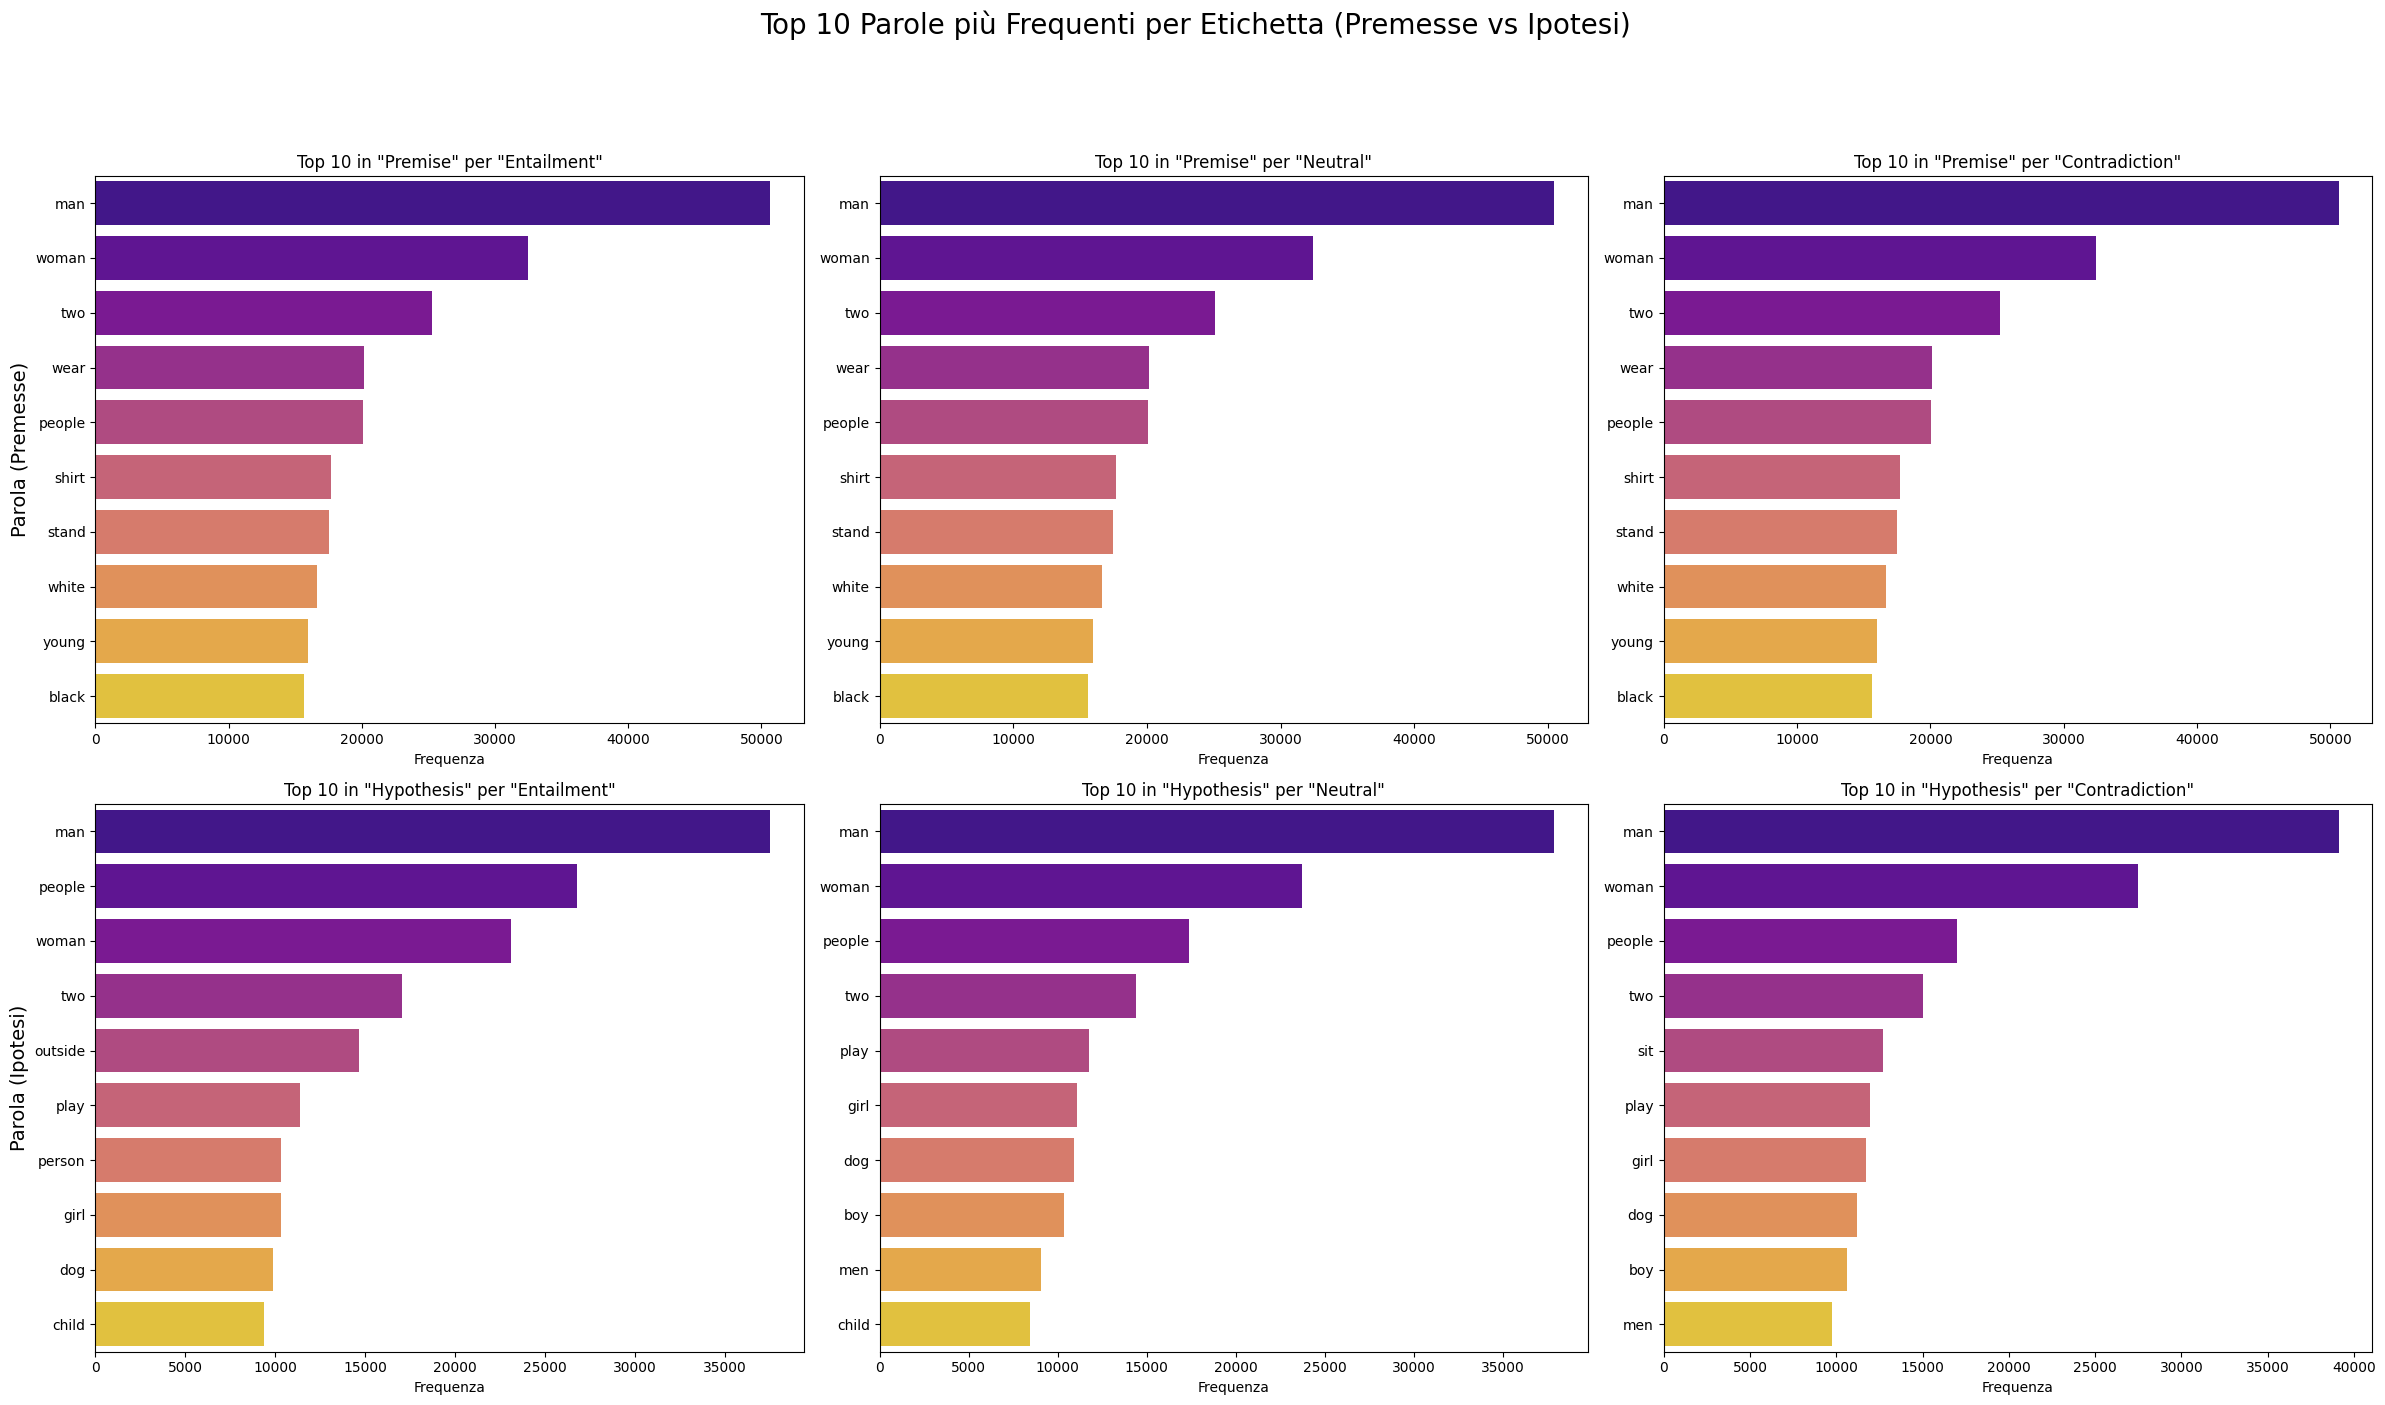

In [ ]:
#=======================================================
#   7. PAROLE PIù COMUNI IN PREMESSA-IPOTESI PER OGNI
#      ETICHETTA
#=======================================================

from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

def plot_top_words_premise_vs_hypothesis(df):
    """
    Crea 6 istogrammi per visualizzare le 10 parole più comuni, separando
    le premesse dalle ipotesi per ogni etichetta.
    """
    labels_to_plot = [label for label in Golden_labels if label != '-']
    sentence_types = {'sentence1': 'Premise', 'sentence2': 'Hypothesis'}

    # Creiamo una griglia di 2 righe (premise/hypothesis) e 3 colonne (labels)
    fig, axs = plt.subplots(nrows=2, ncols=len(labels_to_plot), figsize=(24, 14))
    fig.suptitle('Top 10 Parole più Frequenti per Etichetta (Premesse vs Ipotesi)', fontsize=20, y=1.03)

    for col_idx, label in enumerate(labels_to_plot):
        for row_idx, (col_name, title_name) in enumerate(sentence_types.items()):

            # Seleziona l'asse corretto per il plot
            ax = axs[row_idx, col_idx]

            # Filtra il DataFrame per l'etichetta corrente
            label_df = df[df['gold_label'] == label].copy()

            # Seleziona solo la colonna di interesse (premise o hypothesis)
            corpus = label_df[col_name].dropna().tolist()

            # Applica la TUA esatta funzione di preprocessing
            processed_corpus = preprocess_corpus(corpus)

            # Estrai e conta le parole
            all_words = [word for sentence in processed_corpus for word in sentence.split()]
            word_counts = Counter(all_words)
            top_10_words = word_counts.most_common(10)

            if top_10_words:
                top_df = pd.DataFrame(top_10_words, columns=['Parola', 'Frequenza'])

                sns.barplot(x='Frequenza', y='Parola', data=top_df, ax=ax, palette='plasma')
                ax.set_title(f'Top 10 in "{title_name}" per "{label.capitalize()}"', fontsize=12)
                ax.set_xlabel('Frequenza')
                ax.set_ylabel('') # Rimuoviamo l'etichetta y per pulizia
            else:
                ax.set_title(f'Nessuna parola per "{title_name}" / "{label.capitalize()}"', fontsize=12)
                ax.axis('off')

    # Aggiungi le etichette delle righe per chiarezza
    axs[0, 0].set_ylabel('Parola (Premesse)', fontsize=14)
    axs[1, 0].set_ylabel('Parola (Ipotesi)', fontsize=14)

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()
plot_top_words_premise_vs_hypothesis(df_train)

**Cella 8: Dataset Wrapper per PyTorch**

Il DataLoader di PyTorch è uno strumento per gestire i dati, ma per funzionare necessita di un oggetto Dataset che gli spieghi come sono strutturati i dati e come accedervi. Il codice in questa cella definisce proprio questo: una classe personalizzata, NLIDataset_logisticreg, che agisce come un contenitore standardizzato per le nostre matrici TF-IDF e le relative etichette.

La classe eredita dalla classe base Dataset di PyTorch e implementa tre metodi fondamentali:

    __init__: Il costruttore che inizializza l'oggetto con il nostro corpus di dati e le etichette.

    __len__: Un metodo semplice che comunica al DataLoader la dimensione totale del dataset.

    __getitem__: Il metodo più importante, che definisce come il DataLoader può recuperare un singolo campione dal dataset fornendo un indice.

In sintesi, questa classe non modifica i dati, ma li incapsula in una struttura che PyTorch comprende, abilitando un caricamento dei dati efficiente e organizzato durante l'addestramento.


In [ ]:
#================================
# 8. FUNZIONE WRAPPER PER DATALOADER
#================================
from torch.utils.data import Dataset, DataLoader

class NLIDataset_logisticreg(Dataset):
    def __init__(self, corpus, labels):
        self.corpus = corpus
        self.labels = labels

    def __len__(self): # Funzione che "comunica" a DataLoader la lunghezza del dataset
        return len(self.labels)

    def __getitem__(self, idx): # Funzione che permette al dataloader di prelevare gli indici
        return self.corpus[idx], self.labels[idx]

**Definizione delle Componenti di Addestramento**

Questa cella di codice imposta due delle configurazioni più importanti, valide per l'intero progetto, che determinano dove e come il modello imparerà.

-Selezione del Device (device): La prima riga di codice è un controllo per l'accelerazione hardware. Verifica se è disponibile una GPU compatibile con CUDA. In caso affermativo, imposta il device su 'cuda', istruendo PyTorch a eseguire tutti i calcoli intensivi (come le moltiplicazioni di matrici) sulla GPU, il che accelera drasticamente i tempi di addestramento. In caso contrario, ripiega sulla CPU ('cpu').

-Definizione della Funzione di Costo (criterion): La seconda riga definisce la loss function, ovvero la metrica che guiderà l'apprendimento del modello. Viene scelta la nn.CrossEntropyLoss. Questa funzione di costo è lo standard per i problemi di classificazione multi-classe. Confronta i punteggi grezzi (logit) prodotti dal modello con l'etichetta reale e calcola un valore di "errore" che il processo di backpropagation cercherà di minimizzare. Includendo al suo interno la funzione Softmax, è numericamente stabile e molto efficiente.

In [ ]:
#======================================================================================
# DEFINIZIONE METRICA E DEVICE  DI ADDESTRAMENTO PER TUTTO IL PROGETTO
#======================================================================================
import torch
import torch.nn as nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'
criterion = nn.CrossEntropyLoss()

**Cella 9: Esperimento sui Dati: Unigrammi contro Bigrammi**

Per il nostro modello baseline di Regressione Logistica, non ci limitiamo a una singola configurazione. Vogliamo investigare come la rappresentazione del testo influenzi le performance. Un approccio basato solo su singole parole (unigrammi) potrebbe perdere informazioni contestuali importanti (ad esempio, il significato di "non buono" è diverso dalla somma di "non" e "buono"). Per questo motivo, in questa cella, confronteremo un modello addestrato su unigrammi con uno addestrato su bigrammi (coppie di parole consecutive).

Il codice crea due set di dati distinti, partendo dallo stesso testo lemmatizzato.

Per prima cosa, vengono creati due diversi vettorizzatori TF-IDF, entrambi addestrati sul corpus di training. Il primo (vectorizer_uni) è configurato per considerare solo singole parole (ngram_range=(1, 1)), mentre il secondo (vectorizer_bi) è istruito a considerare solo coppie di parole adiacenti (ngram_range=(2, 2)). Per entrambi, limitiamo il vocabolario alle 2000 feature più frequenti per mantenere gestibile la dimensionalità.

Successivamente, ognuno di questi vettorizzatori viene utilizzato per trasformare i dati di validazione e test. È fondamentale che la trasformazione dei set di validazione e test utilizzi sempre il vocabolario appreso esclusivamente dal training set, per garantire una valutazione corretta. Questo processo genera due pipeline di matrici TF-IDF completamente separate: una per gli unigrammi e una per i bigrammi.

Infine tutte queste matrici vengono convertite in tensori sparsi PyTorch per ottimizzare l'uso della memoria. Il risultato finale è la creazione di due set completi di oggetti Dataset (train_dataset_uni, val_dataset_uni, etc., e train_dataset_bi, val_dataset_bi, etc.). Questi due gruppi di dati sono ora pronti per essere utilizzati in due cicli di addestramento separati, permettendoci di valutare quale rappresentazione testuale—la singola parola o la coppia di parole—fornisce al nostro modello di Regressione Logistica le informazioni più utili per risolvere il task.

In [ ]:
# ===================================================================================
#   9. CARICAMENTO DATI PER LOGISTIC REGRESSION CON TF-IDF SIA UNIGRAMMI CHE BIGRAMMI
# ===================================================================================

import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix


# 1. Funzione per la creazione della matrice TF-IDF
train_lemmatizzato = preprocess_corpus(df_train['combined_text'])
vectorizer_1, train_matrix_1 = fit_vectorizer(train_lemmatizzato, ngram=1) # Unigrammi
vectorizer_2, train_matrix_2 = fit_vectorizer(train_lemmatizzato, ngram=2) # Bigrammi


# 2. Applicazione della matrice ai dataset di validazione e test
val_lemmatizzato = preprocess_corpus(df_val['combined_text'])
val_tf_idf_1 = vectorizer_1.transform(val_lemmatizzato) # Unigrammi
val_tf_idf_2 = vectorizer_2.transform(val_lemmatizzato) # Bigrammi
test_lemmatizzato = preprocess_corpus(df_test['combined_text'])
test_tf_idf_1 = vectorizer_1.transform(test_lemmatizzato) # Unigrammi
test_tf_idf_2 = vectorizer_2.transform(test_lemmatizzato) # Bigrammi

# 3. Conversione delle etichette del DataFrame in tensori
y_train_tensor = torch.tensor(df_train['gold_label_encoded'].values, dtype=torch.long)
y_val_tensor = torch.tensor(df_val['gold_label_encoded'].values, dtype=torch.long)
y_test_tensor = torch.tensor(df_test['gold_label_encoded'].values, dtype=torch.long)

# 4. Conversione delle matrici sparse SciPy in tensori sparsi PyTorch UNIGRAMMI
X_train_tensor_1 = torch.sparse_csr_tensor(train_matrix_1.indptr, train_matrix_1.indices, train_matrix_1.data, size=train_matrix_1.shape, dtype=torch.float32)
X_val_tensor_1 = torch.sparse_csr_tensor(val_tf_idf_1.indptr, val_tf_idf_1.indices, val_tf_idf_1.data, size=val_tf_idf_1.shape, dtype=torch.float32)
X_test_tensor_1 = torch.sparse_csr_tensor(test_tf_idf_1.indptr, test_tf_idf_1.indices, test_tf_idf_1.data, size=test_tf_idf_1.shape, dtype=torch.float32)
# Bigrammi
X_train_tensor_2 = torch.sparse_csr_tensor(train_matrix_2.indptr, train_matrix_2.indices, train_matrix_2.data, size=train_matrix_2.shape, dtype=torch.float32)
X_val_tensor_2 = torch.sparse_csr_tensor(val_tf_idf_2.indptr, val_tf_idf_2.indices, val_tf_idf_2.data, size=val_tf_idf_2.shape, dtype=torch.float32)
X_test_tensor_2 = torch.sparse_csr_tensor(test_tf_idf_2.indptr, test_tf_idf_2.indices, test_tf_idf_2.data, size=test_tf_idf_2.shape, dtype=torch.float32)

# 6. Creazione delle istanze dei Dataset
# UNIGRAMMI
train_dataset_1 = NLIDataset_logisticreg(X_train_tensor_1, y_train_tensor)
val_dataset_1 = NLIDataset_logisticreg(X_val_tensor_1, y_val_tensor)
test_dataset_1 = NLIDataset_logisticreg(X_test_tensor_1, y_test_tensor)

# BIGRAMMI
train_dataset_2 = NLIDataset_logisticreg(X_train_tensor_2, y_train_tensor)
val_dataset_2 = NLIDataset_logisticreg(X_val_tensor_2, y_val_tensor)
test_dataset_2 = NLIDataset_logisticreg(X_test_tensor_2, y_test_tensor)

# 7. Definizione della funzione personalizzata per il collate
def sparse_collate_fn(batch):
    data = [item[0] for item in batch]
    target = [item[1] for item in batch]
    target = torch.stack(target)
    return data, target

# 8. Creazione dei Dataloader
# Unigrammi
BATCH_SIZE = 64
train_dataloader_lr_uni = DataLoader(train_dataset_1, batch_size=BATCH_SIZE, shuffle=True, collate_fn=sparse_collate_fn)
val_dataloader_lr_uni = DataLoader(val_dataset_1, batch_size=BATCH_SIZE, shuffle=False, collate_fn=sparse_collate_fn)
test_dataloader_lr_uni = DataLoader(test_dataset_1, batch_size=BATCH_SIZE, shuffle=False, collate_fn=sparse_collate_fn)

# Bigrammi
train_dataloader_lr_bi = DataLoader(train_dataset_2, batch_size=BATCH_SIZE, shuffle=True, collate_fn=sparse_collate_fn)
val_dataloader_lr_bi = DataLoader(val_dataset_2, batch_size=BATCH_SIZE, shuffle=False, collate_fn=sparse_collate_fn)
test_dataloader_lr_bi = DataLoader(test_dataset_2, batch_size=BATCH_SIZE, shuffle=False, collate_fn=sparse_collate_fn)

/tmp/ipython-input-3914341983.py:35: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  X_train_tensor_1 = torch.sparse_csr_tensor(train_matrix_1.indptr, train_matrix_1.indices, train_matrix_1.data, size=train_matrix_1.shape, dtype=torch.float32)


**Cella 10: Baseline: Regressione Logistica**

Il codice definisce una classe LogisticRegressionModel che eredita da nn.Module, la classe base per tutti i modelli di rete neurale in PyTorch.

Inizializzazione (__init__)

Nel costruttore viene definito un singolo layer lineare (nn.Linear). Questo strato contiene una matrice di pesi e un bias e impara una trasformazione lineare per mappare il numero di feature di input (la dimensione del nostro vocabolario TF-IDF) al numero di classi di output (3 nel nostro caso).

Forward Pass (forward)

Il metodo forward definisce come i dati fluiscono attraverso il modello per generare una predizione. La particolarità di questa implementazione risiede nella sua capacità di gestire l'input proveniente dal nostro DataLoader personalizzato.

Poiché la nostra funzione sparse_collate_fn restituisce una lista di tensori sparsi per ogni batch, il forward pass deve prima gestire questo formato. Il codice controlla se l'input x è una lista e, in tal caso, converte ogni tensore sparso in un tensore denso e li "impila" (torch.stack) per creare un unico tensore di batch denso. Se l'input è un singolo tensore sparso (ad esempio, con un batch di dimensione 1), viene convertito anch'esso in formato denso.

Questa conversione in un formato denso è un passaggio necessario perché il layer nn.Linear di PyTorch è ottimizzato per operare su matrici dense. Sebbene questa scelta comporti un maggiore utilizzo della memoria, semplifica notevolmente la logica del modello. Una volta che l'input è in formato denso, viene semplicemente passato attraverso il layer lineare per calcolare i punteggi finali (logit) per ogni classe.

In [ ]:
#=========================================================
#   10. LOGISTIC REGRESSION
#          (Baseline)
#=========================================================

class LogisticRegressionModel(nn.Module):

    def __init__(self, n_features, n_classes):
        super().__init__()
        self.linear = nn.Linear(n_features, n_classes)
    def forward(self, x):
        if isinstance(x, list):
            x_dense = torch.stack([item.to_dense() for item in x])
            x = x_dense

        elif x.is_sparse:
             x = x.to_dense()

        return self.linear(x)

Questa cella di codice orchestra l'intero processo di addestramento e valutazione del nostro modello baseline di Regressione Logistica, utilizzando specificamente le feature TF-IDF basate su unigrammi. È il momento in cui tutti i componenti preparati in precedenza—il modello, i dati e le configurazioni—vengono messi al lavoro per insegnare al nostro classificatore a risolvere il task e per misurarne le performance finali.

**Inizializzazione e Configurazione del Training**

Prima che l'addestramento vero e proprio inizi, vengono impostati alcuni parametri fondamentali. Viene definito il numero di epoche (EPOCHS), ovvero quante volte il modello vedrà l'intero set di addestramento. Successivamente, viene creata un'istanza del nostro LogisticRegressionModel, specificando il numero di feature di input (che corrisponde alla dimensione del vocabolario TF-IDF) e il numero di classi di output. Il modello viene quindi spostato sul device prescelto (GPU o CPU) per l'elaborazione. Infine, viene inizializzato l'ottimizzatore Adam, un algoritmo efficiente che si occuperà di aggiornare i pesi del modello durante l'apprendimento, con un learning rate predefinito.

**Ciclo di Addestramento (Training Loop)**

Per ogni epoca, il modello viene messo in modalità di addestramento (model.train()). Il codice itera poi su ogni mini-batch fornito dal train_dataloader_lr_uni, eseguendo la sequenza canonica di operazioni di PyTorch:

-Reset dei Gradienti: I gradienti calcolati nel batch precedente vengono azzerati.

-Spostamento dei Dati: Il batch di input (una lista di tensori sparsi) e le etichette vengono spostati sul device attivo.

-Forward Pass: Il batch di dati viene passato al modello per ottenere le predizioni (logits).

-Calcolo della Loss: Le predizioni vengono confrontate con le etichette reali usando la funzione di costo CrossEntropyLoss per calcolare l'errore.

-Backward Pass (Backpropagation): L'errore viene propagato all'indietro per calcolare come ogni peso del modello abbia contribuito all'errore totale.

-Ottimizzazione: L'ottimizzatore Adam aggiorna i pesi del modello per minimizzare l'errore.

Al termine di ogni epoca, viene stampata la loss media.

**Ciclo di Valutazione (Evaluation Loop)**

Una volta terminato l'addestramento, è cruciale valutare le performance del modello su dati inediti. Il modello viene messo in modalità di valutazione (model.eval()), e l'intero processo viene racchiuso in un blocco torch.no_grad() per disabilitare il calcolo dei gradienti, rendendo l'inferenza più veloce.

Il ciclo itera sul test_dataloader_lr_uni, esegue il forward pass per ottenere le predizioni e le confronta con le etichette reali. Il numero di predizioni corrette viene accumulato. Infine, viene calcolata e stampata l'accuratezza totale, una metrica che ci dice la percentuale di campioni del test set che il nostro modello baseline è stato in grado di classificare correttamente.

In [ ]:
#==================================================================================
#Addestramento del modello di regressione logistica con TF-IDF UNIGRAMMI (BASELINE)
#==================================================================================

EPOCHS = 3
model = LogisticRegressionModel(n_features=X_train_tensor_1.shape[1], n_classes=len(label_encoder.classes_)).to(device)
optimizer = Adam(model.parameters(), lr=0.001)

#Training Loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_dataloader_lr_uni:
        optimizer.zero_grad()
        batch_X = [item.to(device) for item in batch_X]
        batch_y = batch_y.to(device)

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss = {total_loss/len(train_dataloader_lr_uni):.4f}")

#Valutazione
model.eval()
with torch.no_grad():
    total_correct = 0
    total_samples = 0
    for batch_X, batch_y in test_dataloader_lr_uni:
        batch_X = [item.to(device) for item in batch_X]
        batch_y = batch_y.to(device)
        outputs_test = model(batch_X)
        _, preds = torch.max(outputs_test, 1)
        total_correct += (preds == batch_y).sum().item()
        total_samples += batch_y.size(0)
    acc = total_correct / total_samples
    print(f"Test accuracy: {acc:.3f}")

Epoch 1, Loss = 1.0277
Epoch 2, Loss = 0.9794
Epoch 3, Loss = 0.9637
Test accuracy: 0.551


**Analisi dei Risultati**

L'output della cella ci fornisce due informazioni chiave sul comportamento del nostro modello baseline: come ha imparato e quanto bene ha generalizzato.

**Andamento dell'Addestramento (Training)**

L'output delle tre epoche mostra un andamento positivo e coerente. La loss (l'errore del modello) diminuisce costantemente ad ogni epoca, passando da 1.0278 a 0.9637. Questo segnale ci dice che il modello sta imparando con successo dai dati di addestramento. Ad ogni passaggio, l'ottimizzatore sta aggiornando i pesi del modello in modo efficace, riducendo l'errore e migliorando la sua capacità di mappare gli input alle etichette corrette. La discesa graduale suggerisce un processo di apprendimento stabile.

**Performance sul Test Set (Valutazione)**

La metrica più importante è l'accuratezza finale sul test set, che si attesta al 55.2%. Questo risultato è molto significativo per diverse ragioni:

-Supera la Soglia Casuale: In un problema con tre classi bilanciate, un modello che tira a indovinare otterrebbe un'accuratezza di circa il 33.3%. Il nostro 55.2% dimostra che il modello ha appreso pattern reali e significativi nei dati.

-Generalizzazione: Ottenere una buona performance su dati che il modello non ha mai visto prima (il test set) significa che il modello ha generalizzato bene. Non ha semplicemente "imparato a memoria" il training set, ma ha estratto delle regole che si applicano anche a nuovi esempi.

In conclusione, questo output ci conferma che il nostro modello baseline di Regressione Logistica, pur essendo semplice, è un punto di partenza valido e funzionante. Ha imparato con successo e ha dimostrato una capacità predittiva concreta, stabilendo una solida base di riferimento che modelli più complessi dovranno superare.

**Preprocessing per il Modello LSTM**

Ora implementiamo una tecnica più moderna e potente, basata su una rete neurale ricorrente LSTM (Long Short-Term Memory). Questo tipo di modello è progettato specificamente per catturare le dipendenze sequenziali e il contesto all'interno del testo, ma richiede una preparazione dei dati completamente diversa. Il codice in questa cella si occupa proprio di questo, trasformando le nostre frasi in un formato numerico che preservi il loro significato semantico e la loro struttura sequenziale.

**Creazione del Vocabolario**

Il primo passo consiste nel costruire un vocabolario personalizzato a partire dal nostro corpus di addestramento. La funzione lstm_vocab analizza tutte le frasi del training set, le scompone in singole parole (token) e conta la frequenza di ciascuna. Per mantenere il vocabolario gestibile ed eliminare il rumore, le parole che compaiono molto raramente (meno di una soglia min_freq) vengono scartate. A ogni parola rimanente viene poi assegnato un indice numerico univoco. Vengono inoltre aggiunti due token speciali: <PAD>, che useremo per riempire le frasi più corte, e <UNK> (unknown), che rappresenterà tutte le parole che il modello incontrerà in futuro ma che non sono presenti nel vocabolario.

**Embedding Pre-addestrati GloVe**

Una semplice mappatura da parole a interi non cattura alcuna relazione semantica. Per superare questo limite, utilizziamo word embeddings pre-addestrati, nello specifico GloVe (Global Vectors for Word Representation).  Questi sono vettori numerici di dimensione fissa (nel nostro caso 300) che sono stati addestrati su un'enorme quantità di testo. La loro particolarità è che la loro posizione in uno spazio vettoriale cattura le relazioni semantiche e sintattiche tra le parole. Il codice si occupa di scaricare questi vettori e di caricarli in memoria.

Successivamente, viene creata una matrice di embedding. Questa matrice funge da "ponte" tra il nostro vocabolario e i vettori GloVe. Per ogni parola nel nostro vocabolario, cerchiamo il suo vettore corrispondente in GloVe e lo inseriamo nella riga della matrice corrispondente all'indice di quella parola. Il risultato è una grande tabella di ricerca che il nostro modello userà per convertire istantaneamente ogni parola nel suo ricco vettore semantico.

**Numericalizzazione e Padding**

I modelli di rete neurale richiedono input di dimensione fissa. Le nostre frasi, tuttavia, hanno lunghezze variabili. Per risolvere questo problema, il codice esegue due operazioni finali. Prima di tutto, ogni frase (sia premessa che ipotesi) viene numericalizzata, ovvero ogni parola viene sostituita con il suo indice corrispondente dal nostro vocabolario. Successivamente, viene applicato il padding: le frasi più corte della lunghezza massima definita (max_len) vengono riempite con il token <PAD>, mentre quelle più lunghe vengono troncate.

Al termine di questo processo, che viene applicato separatamente a premesse e ipotesi per tutti e tre i set di dati, otteniamo delle sequenze numeriche di lunghezza uniforme, pronte per essere date in input al layer di embedding del nostro modello LSTM.



**Cella 11: Prerpocessing LSTM**

**Costruzione del Vocabolario**

Il primo passo è convertire le parole, che sono stringhe, in numeri che il modello possa elaborare. La funzione lstm_vocab si occupa proprio di questo. Analizza l'intero corpus di addestramento, lo scompone in singole parole (token) e conta la frequenza di ciascuna. Per mantenere il vocabolario pulito e di dimensioni gestibili, le parole che compaiono molto raramente (meno di una soglia min_freq) vengono scartate.

A ogni parola rimanente viene poi assegnato un indice numerico unico. La funzione aggiunge anche due token speciali cruciali:

-<PAD> (Padding): Sarà utilizzato in seguito per rendere tutte le frasi della stessa lunghezza, un requisito per l'elaborazione in batch.

-<UNK> (Unknown): Rappresenterà tutte le parole che il modello incontrerà durante la validazione o il test ma che non erano presenti nel vocabolario di addestramento.

Il risultato è un dizionario che funge da traduttore tra il nostro testo e il mondo numerico del modello.

**GloVe Word Embeddings**

Una semplice mappatura da parole a indici non cattura alcuna relazione di significato. Per superare questo limite, sfruttiamo i word embeddings pre-addestrati, in particolare GloVe (Global Vectors for Word Representation).

Questi non sono semplici numeri, ma vettori densi (nel nostro caso, di 300 dimensioni) che sono stati addestrati su miliardi di parole. La loro posizione in uno spazio vettoriale cattura complesse relazioni semantiche e sintattiche. Il codice in questa cella automatizza il processo di download e decompressione di questi vettori.

Successivamente, il file di testo di GloVe viene letto riga per riga. Ogni riga contiene una parola seguita dal suo vettore numerico. Il codice popola un dizionario, embeddings_index, che funge da enorme "libro di consultazione" dal quale potremo, in seguito, recuperare il vettore di significato per ogni parola nel nostro vocabolario. In questo modo, "iniettiamo" nel nostro modello una profonda conoscenza del linguaggio prima ancora che inizi l'addestramento sui nostri dati specifici.

In [ ]:
#================================
#   11. PREPROCESSING PER LSTM
#          Approccio (2)
#================================


from collections import Counter
import itertools
import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
import numpy as np

nltk.download('punkt_tab')

# 6.1 Costruzione del Vocabolario
def lstm_vocab(corpus_list, min_freq=2):
    # Tokenizzazione di tutte le frasi
    all_tokens = [nltk.word_tokenize(str(text).lower()) for text in corpus_list if isinstance(text, str)]

    # Unisce tutte le liste di token in una singola lista
    all_tokens_flat = list(itertools.chain.from_iterable(all_tokens))

    word_counts = Counter(all_tokens_flat)

    # Filtra le parole che non raggiungono la frequenza minima
    filtered_vocab = {word for word, count in word_counts.items() if count >= min_freq}

    # Crea la mappatura da parola all' indice
    # Assegna indici speciali per il padding (<PAD>) e le parole sconosciute (<UNK>)
    word_to_idx = {word: idx + 2 for idx, word in enumerate(sorted(list(filtered_vocab)))}
    word_to_idx['<PAD>'] = 0
    word_to_idx['<UNK>'] = 1

    return word_to_idx

# 6.2 GloVe
!pip install -q gdown
import gdown

gdown.download('http://nlp.stanford.edu/data/glove.6B.zip', 'glove.6B.zip', quiet=False)

with zipfile.ZipFile('glove.6B.zip', 'r') as z:
    z.extractall('.')

GloVe_path = 'glove.6B.300d.txt'

# 6.3 Caricamento degli embedding in un dizionario
embeddings_index = {}
f = open('glove.6B.300d.txt', encoding='utf-8')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

print(f'Trovati {len(embeddings_index)} word vectors.')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
Downloading...
From: http://nlp.stanford.edu/data/glove.6B.zip
To: /content/glove.6B.zip
100%|██████████| 862M/862M [03:01<00:00, 4.76MB/s]


Trovati 400000 word vectors.


**Matrice di Embedding**

Dopo aver creato il nostro vocabolario e caricato i vettori GloVe, dobbiamo collegarli. La funzione glove_embedding agisce come un "ponte", creando una matrice di embedding. Questa non è altro che una grande tabella di ricerca: per ogni parola nel nostro vocabolario, la funzione cerca il suo vettore GloVe corrispondente e lo inserisce nella riga della matrice associata a quella parola.

Il risultato è una matrice in cui ogni riga i contiene il vettore di 300 dimensioni della parola con indice i nel nostro vocabolario. Questa matrice verrà caricata direttamente nel layer di embedding del nostro modello, "iniettandogli" una profonda conoscenza linguistica fin dal primo momento.

**Numericalizzazione e Padding**

Le reti neurali richiedono input di dimensione fissa, ma le nostre frasi hanno lunghezze variabili. La funzione numericalize_and_pad_from_tokens risolve questo problema con due operazioni:

-Numericalizzazione: Ogni frase (già scomposta in parole/token) viene convertita in una sequenza di numeri. Ogni parola viene sostituita con il suo indice corrispondente dal nostro vocabolario (word_to_idx). Se una parola non è presente nel vocabolario, le viene assegnato l'indice del token speciale <UNK>.

-Padding: Le sequenze numeriche vengono poi portate tutte alla stessa lunghezza (max_len). Le frasi più corte vengono "riempite" con l'indice del token <PAD>, mentre quelle più lunghe vengono troncate.

**Preparazione Finale dei Dati**

La parte finale della cella orchestra l'intero processo. Per prima cosa, crea il vocabolario e la matrice di embedding GloVe utilizzando esclusivamente i dati di addestramento, fondamentale per evitare data leakage.

Successivamente, la funzione process_s1_s2 applica la tokenizzazione, la numericalizzazione e il padding separatamente alle premesse e alle ipotesi per tutti e tre i set di dati (training, validazione e test). Questo è un passaggio cruciale: il modello LSTM riceverà due input distinti, uno per la premessa e uno per l'ipotesi, e imparerà a modellarne la relazione. Al termine, i nostri dati testuali sono stati trasformati in sequenze numeriche di lunghezza fissa, pronte per essere convertite in tensori PyTorch e date in pasto al modello.

In [ ]:

# 6.4 Funzione GloVe embedding
def glove_embedding(word_to_idx, embeddings_index):

  missing_embeddings = [word for word in word_to_idx if word not in embeddings_index]
  print(f"Numero parole mancanti:", {len(missing_embeddings)})
  # Associazione embeddings al vocabolario
  embedding_matrix = np.zeros((len(word_to_idx), 300))
  for word, idx in word_to_idx.items():
    if word in embeddings_index:
      embedding_matrix[idx] = embeddings_index[word]
  return embedding_matrix

# 6.5 Funzione per Pad
def numericalize_and_pad_from_tokens(corpus_tokens, word_to_idx, max_len=40):
    numerical_corpus = []
    unk_idx = word_to_idx.get('<UNK>', 1)
    pad_idx = word_to_idx.get('<PAD>', 0)

    for tokens in corpus_tokens:
        numerical_tokens = [word_to_idx.get(token, unk_idx) for token in tokens]

        if len(numerical_tokens) < max_len:
            padded_tokens = numerical_tokens + [pad_idx] * (max_len - len(numerical_tokens))
        else:
            padded_tokens = numerical_tokens[:max_len]

        numerical_corpus.append(padded_tokens)

    return numerical_corpus

# 6.6 Inizializzazione vocabolario solo su training set con liste di premesse e ipotesi messa in unica stringa
word_to_idx = lstm_vocab(df_train['combined_text'].tolist())

# 6.7 Creazione della matrice di embedding GloVe (da fare una sola volta)
glove_matrix = glove_embedding(word_to_idx, embeddings_index)
print("Matrice di GloVe creata con successo.")

# 6.8 Funzione per l'elaborazione dei dati
def process_s1_s2(df, word_to_idx):
    premise_tokens = [nltk.word_tokenize(str(text).lower()) for text in df['sentence1'].tolist()]
    hypothesis_tokens = [nltk.word_tokenize(str(text).lower()) for text in df['sentence2'].tolist()]

    X_premise_numerical = numericalize_and_pad_from_tokens(premise_tokens, word_to_idx)
    X_hypothesis_numerical = numericalize_and_pad_from_tokens(hypothesis_tokens, word_to_idx)

    return X_premise_numerical, X_hypothesis_numerical

# 6.9 Elaborazione dei dati per ogni set
X_premise_train_numerical, X_hypothesis_train_numerical = process_s1_s2(df_train, word_to_idx)
X_premise_val_numerical, X_hypothesis_val_numerical = process_s1_s2(df_val, word_to_idx)
X_premise_test_numerical, X_hypothesis_test_numerical = process_s1_s2(df_test, word_to_idx)

print("Pre-elaborazione completata per tutti i set di dati.")



Numero parole mancanti: {3501}
Matrice di GloVe creata con successo.
Pre-elaborazione completata per tutti i set di dati.


**Cella 12: Strutturare i Dati per l'LSTM**

Dopo la fase di preprocessing, in cui abbiamo trasformato le nostre frasi in sequenze numeriche di lunghezza fissa, è il momento di compiere l'ultimo passo preparatorio: organizzare questi dati in una struttura ottimizzata per l'addestramento con PyTorch. Questa cella prende i nostri dati grezzi e li confeziona in batch pronti per essere processati dalla rete neurale.

Il primo passaggio è la conversione in tensori. Le nostre sequenze numeriche, che al momento sono semplici liste Python, vengono trasformate in torch.tensor di tipo long. I tensori sono l'equivalente PyTorch degli array NumPy, ma con il vantaggio di poter essere spostati ed elaborati in modo estremamente efficiente sulle GPU, accelerando drasticamente i calcoli. Questa conversione viene applicata a tutte le nostre sequenze (premesse e ipotesi) e alle etichette per ogni set di dati.

Successivamente, per gestire la complessità dei nostri input (ora composti da due sequenze separate, premessa e ipotesi, più un'etichetta), definiamo una classe NLIDataset personalizzata. Questa classe agisce come un contenitore intelligente. Il suo scopo è insegnare a PyTorch come sono strutturati i nostri dati, specificando che ogni singolo campione è una tripla composta da un tensore per la premessa, un tensore per l'ipotesi e la sua etichetta corrispondente. Attraverso i metodi __len__ e __getitem__, forniamo al framework le istruzioni essenziali per sapere quanti campioni ci sono in totale e come prelevarne uno specifico.

Infine, con i dati incapsulati nel nostro Dataset, creiamo i DataLoader. Questi sono iteratori che automatizzano il processo di alimentazione del modello. Il DataLoader si occupa di raggruppare i campioni in mini-batch della dimensione desiderata (BATCH_SIZE). Per il solo set di addestramento, il DataLoader esegue anche lo shuffling, ovvero mescola i dati ad ogni epoca. Questa operazione è importante per evitare che il modello impari l'ordine sequenziale degli esempi, migliorando la sua capacità di generalizzare. Il risultato finale è un flusso di dati perfettamente organizzato e pronto per essere inviato al modello LSTM.

In [ ]:
#=========================================================
#   12. CARICAMENTO DATI PER LSTM E TREE-LSTM
#=========================================================

from torch.utils.data import Dataset, DataLoader
#from sklearn.preprocessing import LabelEncoder
import torch

# 12.1 Inizializzazione vocabolario solo su training set con liste di premesse e ipotesi messa in unica stringa
word_to_idx = lstm_vocab(df_train['combined_text'].tolist())

# 12.2 Trasformazione per tutte le frasi nei dataset

X_premise_train_numerical = numericalize_and_pad_from_tokens(df_train['sentence1'], word_to_idx)
X_hypothesis_train_numerical = numericalize_and_pad_from_tokens(df_train['sentence2'], word_to_idx)
X_premise_val_numerical = numericalize_and_pad_from_tokens(df_val['sentence1'], word_to_idx)
X_hypothesis_val_numerical = numericalize_and_pad_from_tokens(df_val['sentence2'], word_to_idx)
X_premise_test_numerical = numericalize_and_pad_from_tokens(df_test['sentence1'], word_to_idx)
X_hypothesis_test_numerical = numericalize_and_pad_from_tokens(df_test['sentence2'], word_to_idx)

# 12.3 Converte numpy arrays a tensori
X_premise_train_numerical_tensor = torch.tensor(X_premise_train_numerical, dtype=torch.long)        # TRAIN
X_hypothesis_train_numerical_tensor = torch.tensor(X_hypothesis_train_numerical, dtype=torch.long)
y_train_tensor = torch.tensor(df_train['gold_label_encoded'].values, dtype=torch.long)

X_premise_val_numerical_tensor = torch.tensor(X_premise_val_numerical, dtype=torch.long)            # VALIDATION
X_hypothesis_val_numerical_tensor = torch.tensor(X_hypothesis_val_numerical, dtype=torch.long)
y_val_tensor = torch.tensor(df_val['gold_label_encoded'].values, dtype=torch.long)

X_premise_test_numerical_tensor = torch.tensor(X_premise_test_numerical, dtype=torch.long)          # TEST
X_hypothesis_test_numerical_tensor = torch.tensor(X_hypothesis_test_numerical, dtype=torch.long)
y_test_tensor = torch.tensor(df_test['gold_label_encoded'].values, dtype=torch.long)

# 12.4 Creazione del dataset da utilizzare
class NLIDataset(Dataset):
    def __init__(self, premise, hypothesis, labels):
        self.premise = premise
        self.hypothesis = hypothesis
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.premise[idx], self.hypothesis[idx], self.labels[idx]

# 12.5 Creazione delle istanze dei dataset
train_dataset = NLIDataset(X_premise_train_numerical_tensor, X_hypothesis_train_numerical_tensor, y_train_tensor)
val_dataset = NLIDataset(X_premise_val_numerical_tensor, X_hypothesis_val_numerical_tensor, y_val_tensor)
test_dataset = NLIDataset(X_premise_test_numerical_tensor, X_hypothesis_test_numerical_tensor, y_test_tensor)

# 12.6 Creazione dei dataloader
BATCH_SIZE = 64
train_dataloader_lstm = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader_lstm = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader_lstm = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created successfully.")

DataLoaders created successfully.


Questa cella definisce un modello di rete neurale basato su LSTM (Long Short-Term Memory), progettato specificamente per il task di Natural Language Inference. A differenza della regressione logistica, che tratta le frasi come bag-of-words, questo modello è in grado di leggere e interpretare le frasi in sequenza, catturando il contesto e le dipendenze a lungo termine tra le parole. L'architettura è costruita per codificare la relazione tra premessa e ipotesi.

**I Componenti Fondamentali del Modello**

La costruzione del modello, definita nel metodo __init__, si basa su tre componenti principali:

**Layer di Embedding:** Il primo strato è un nn.Embedding. Il suo compito è convertire le sequenze di indici numerici (che rappresentano le parole) in vettori densi e di significato. Inizializziamo questo layer con la matrice GloVe che abbiamo preparato in precedenza. Questo significa che, fin dal primo momento, il nostro modello possiede una ricca conoscenza semantica del linguaggio. Un parametro cruciale, freeze_embeddings, ci permette di "congelare" i pesi di questo strato, impedendo al modello di modificarli durante l'addestramento. Questo preserva la conoscenza generale di GloVe e accelera l'addestramento.

**Il Core LSTM**: Il layer nn.LSTM è una rete ricorrente che processa le sequenze di vettori di embedding parola per parola, mantenendo uno stato interno (hidden state e cell state) che si aggiorna ad ogni passo. Questo stato agisce come una memoria, accumulando una rappresentazione contestuale dell'intera sequenza letta fino a quel momento.

**Il Classificatore (MLP)**: Dopo che l'LSTM ha elaborato le sequenze, l'informazione estratta viene passata a un classificatore. In questo caso, si tratta di un Multi-Layer Perceptron (MLP), una piccola rete neurale feed-forward composta da alcuni strati lineari, funzioni di attivazione ReLU e strati di Dropout. Il dropout è una tecnica di regolarizzazione fondamentale che aiuta a prevenire l'overfitting spegnendo casualmente alcuni neuroni durante l'addestramento. Il compito di questo blocco è prendere la rappresentazione finale generata dall'LSTM e mapparla sulle tre classi di output (entailment, neutral, contradiction).

Successivamente il metodo forward definisce come i dati fluiscono attraverso i componenti del modello. L'approccio utilizzato è una forma di codifica condizionale:

**Codifica della Premessa**: Per prima cosa, la premessa viene passata attraverso il layer di embedding e poi processata dall'LSTM. L'LSTM scorre l'intera premessa e ne produce una rappresentazione finale compressa nei suoi stati interni (hidden e cell state). Questi stati possono essere visti come un "riassunto" del significato semantico della premessa.

**Codifica Condizionata dell'Ipotesi**: Qui avviene il passaggio chiave. L'ipotesi viene anch'essa convertita in embedding, ma quando viene passata allo stesso LSTM, gli stati iniziali della rete non sono zero, ma vengono impostati sugli stati finali ottenuti dalla lettura della premessa. Questo significa che l'LSTM inizia a leggere l'ipotesi avendo già "in mente" il contesto completo della premessa. Mentre processa l'ipotesi, il modello non sta solo interpretando la frase in isolamento, ma sta attivamente cercando relazioni, implicazioni e contraddizioni rispetto al contesto fornito.

**Classificazione Finale**: Lo stato nascosto finale, ottenuto dopo aver letto l'ipotesi in questo modo condizionato, rappresenta una sintesi ricca della relazione tra le due frasi. Questo vettore finale viene quindi passato al classificatore MLP, che produce i logit (i punteggi grezzi) per la classificazione finale.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import adam

class LSTMNLIModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, embedding_matrix=None, freeze_embeddings=True):
        super(LSTMNLIModel, self).__init__()

        self.hidden_dim = hidden_dim

        # Layer per l'embedding delle parole
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)

        self.word_embeddings.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.word_embeddings.weight.requires_grad = not freeze_embeddings

        # LSTM per processare le sequenze
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

        # Layer finale per la classificazione
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim//2, num_classes)
        )

    def forward(self, premise_batch, hypothesis_batch):
        # 1. Processare la premessa
        premise_embeds = self.word_embeddings(premise_batch)

        # 'h_n_premise' e 'c_n_premise' sono gli stati finali dell'LSTM dopo aver processato la premessa, "_" è l'output di ogni passo temporale
        _, (h_n_premise, c_n_premise) = self.lstm(premise_embeds)

        # 2. Processare l'ipotesi usando gli stati finali della premessa come stati iniziali
        hypothesis_embeds = self.word_embeddings(hypothesis_batch)

        # Passiamo la rappresentazione della premessa come hidden state iniziale all'LSTM per l'ipotesi.
        _, (h_n_hypothesis, c_n_hypothesis) = self.lstm(hypothesis_embeds, (h_n_premise, c_n_premise))

        # L'ultimo hidden state dell'ipotesi 'h_n_hypothesis' è la rappresentazione combinata di premessa e ipotesi. La usiamo per la classificazione.
        # Rimodelliamo l'output per la classificazione (da 3D a 2D)
        final_state = h_n_hypothesis.squeeze(0)

        # 3. Classificazione finale
        logits = self.classifier(final_state)

        return logits


VOCAB_SIZE = len(word_to_idx)
EMBEDDING_DIM = 300
HIDDEN_DIM = 64
NUM_CLASSES = 3
SEQ_LENGTH_P = 40
SEQ_LENGTH_H = 40
embedding_matrix = glove_embedding(word_to_idx, embeddings_index)
print("Embedding matrix shape:", embedding_matrix.shape)

#print("Forma dell'output del modello:", output.shape)


Numero parole mancanti: {3501}
Embedding matrix shape: (25592, 300)


**Ricerca dei Migliori Iperparametri**

In questa cella viene fatta una Grid Search degli iperparametri.

Prima di tutto, la funzione tune_model riceve una griglia di parametri (param_grid), che è un dizionario contenente gli iperparametri da testare e i possibili valori per ciascuno di essi. Utilizzando ParameterGrid di Scikit-learn, la funzione genera ogni singola combinazione possibile di questi valori.

Successivamente, per ciascuna combinazione, la funzione esegue un ciclo completo di addestramento e valutazione. Inizializza un nuovo modello con la configurazione corrente, lo addestra per un numero limitato di epoche sul training set e poi ne misura le performance sul validation set. È fondamentale usare il set di validazione per questo scopo, e non il test set, per evitare di "inquinare" la nostra valutazione finale con le scelte fatte durante l'ottimizzazione.

Come metrica per giudicare quale modello sia il "migliore", la funzione utilizza l'F1-score, una metrica di classificazione robusta che bilancia precision e recall. La combinazione di iperparametri che ottiene l'F1-score più alto sul set di validazione viene salvata come la migliore.

Infine, una volta esplorate tutte le combinazioni, la funzione non si limita a riportare la configurazione migliore. Prende il modello che ha ottenuto le migliori performance sul validation set e lo valuta un'ultima volta sull'inedito test set. Questo passaggio finale ci fornisce una stima onesta e affidabile di come il nostro modello, nella sua configurazione ottimale, si comporterà su dati completamente nuovi.

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score
import numpy as np

def tune_model(model_type, model_class, param_grid, train_loader, val_loader, test_dataloader, device, criterion, label_encoder, **kwargs):

    best_f1 = -1
    best_params = None
    best_model= None
    grid = ParameterGrid(param_grid)

    print(f"Starting hyperparameter tuning for {model_type} model...")
    print(f"Number of hyperparameter combinations: {len(grid)}")

    for params in grid:
        print(f"\nValidating these parameters: {params}")

        if model_type == 'logistic_regression':
            model = model_class(n_features=kwargs['n_features'], n_classes=kwargs['n_classes'])
        elif model_type == 'lstm':
            model = model_class(vocab_size=kwargs['vocab_size'],
                                embedding_dim=kwargs['embedding_dim'],
                                hidden_dim=params['hidden_dim'],
                                num_classes=kwargs['num_classes'],
                                embedding_matrix=kwargs.get('embedding_matrix'))
        else:
            raise ValueError("Unsupported model_type.")

        model.to(device)

        optimizer = Adam(model.parameters(), lr=params['lr'])

        TUNING_EPOCHS = 5

        for epoch in range(TUNING_EPOCHS):
            model.train()
            total_loss = 0
            for batch in train_loader:
                optimizer.zero_grad()
                if model_type == 'lstm':
                    batch_premise, batch_hypothesis, batch_y = batch
                    batch_premise, batch_hypothesis, batch_y = batch_premise.to(device), batch_hypothesis.to(device), batch_y.to(device)
                    outputs = model(batch_premise, batch_hypothesis)
                elif model_type == 'logistic_regression':
                     batch_X, batch_y = batch
                     batch_X = [item.to(device) for item in batch_X]
                     batch_y = batch_y.to(device)
                     outputs = model(batch_X)

                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()


        # Validation Step
        model.eval()
        all_val_preds = []
        all_val_labels = []
        with torch.no_grad():
            for batch in val_loader:
                 if model_type == 'lstm':
                    batch_premise, batch_hypothesis, batch_y = batch
                    batch_premise, batch_hypothesis, batch_y = batch_premise.to(device), batch_hypothesis.to(device), batch_y.to(device)
                    outputs = model(batch_premise, batch_hypothesis)
                 elif model_type == 'logistic_regression':
                     batch_X, batch_y = batch
                     batch_X = [item.to(device) for item in batch_X]
                     batch_y = batch_y.to(device)
                     outputs = model(batch_X)

                 _, preds = torch.max(outputs, 1)
                 all_val_preds.extend(preds.cpu().numpy())
                 all_val_labels.extend(batch_y.cpu().numpy())

        f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
        print(f"  Validation F1-score: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_params = params
            best_model = model
            print("  Found new best parameters!")

    print("\nHyperparameter tuning finished.")
    print(f"Best validation F1-score: {best_f1:.4f}")
    print(f"Best parameters: {best_params}")
    return best_params


**Funzione di Addestramento**

La funzione train_final_model è progettata per essere flessibile e gestire l'addestramento di entrambi i nostri modelli, la Regressione Logistica e l'LSTM, tenendo conto delle loro specifiche necessità.

**Logica Generale del Training Loop**

Il cuore della funzione è il ciclo di addestramento, che itera per un numero predefinito di epoche. Per ogni epoca, il modello viene messo in modalità di addestramento (model.train()), e la funzione inizia a ciclare attraverso i mini-batch di dati forniti dal train_loader. Per ogni batch, vengono eseguiti i passaggi canonici dell'addestramento in PyTorch:

-Reset dei Gradienti (optimizer.zero_grad()): I gradienti calcolati nel batch precedente vengono azzerati.

-Forward Pass: I dati del batch vengono passati al modello per ottenere le predizioni.

-Calcolo della Loss (criterion()): L'errore del modello viene calcolato confrontando le predizioni con le etichette reali.

-Backward Pass (loss.backward()): L'errore viene propagato all'indietro per calcolare i gradienti.

-Aggiornamento dei Pesi (optimizer.step()): L'ottimizzatore aggiorna i pesi del modello per minimizzare l'errore.

**Gestione dei Diversi Tipi di Modello**

Una caratteristica chiave di questa funzione è la sua capacità di adattarsi ai diversi formati di input dei nostri due modelli. Un blocco if/elif controlla il model_type:

-Per l'LSTM, sa che il batch è composto da tre tensori (premessa, ipotesi, etichetta) e li passa al modello di conseguenza.

-Per la Regressione Logistica, sa che il batch di input è una lista di tensori sparsi e li gestisce come richiesto dal modello.

Al termine del ciclo di addestramento, la funzione restituisce l'istanza del modello, ora "addestrato" e con i pesi aggiornati, pronto per la fase di valutazione.

In [ ]:
#=====================
# FUNZIONE DI TRAINING
#=====================

def train_final_model(model, train_loader, val_loader, device, criterion, optimizer, epochs, model_type):

    print(f"Starting final training for {epochs} epochs...")
    best_val_accuracy = -1
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            if model_type == 'lstm':
                batch_premise, batch_hypothesis, batch_y = batch
                batch_premise, batch_hypothesis, batch_y = batch_premise.to(device), batch_hypothesis.to(device), batch_y.to(device)
                outputs = model(batch_premise, batch_hypothesis)
            elif model_type == 'logistic_regression':
                 batch_X, batch_y = batch
                 batch_X = [item.to(device) for item in batch_X]
                 batch_y = batch_y.to(device)
                 outputs = model(batch_X)

            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)


    return model

**Inferenza e Raccolta Dati**

Il processo inizia mettendo il modello in modalità di valutazione (model.eval()) e disabilitando il calcolo dei gradienti (torch.no_grad()). Questo assicura che il modello si comporti in modo deterministico e che l'inferenza sia efficiente. La funzione itera quindi su tutti i dati del test_dataloader, che il modello non ha mai visto prima. Grazie a un blocco condizionale, è in grado di gestire in modo flessibile i diversi formati di input dei nostri due modelli (LSTM e Regressione Logistica). Per ogni batch, raccoglie tre informazioni cruciali: le etichette predette, le etichette reali e i "logit", ovvero i punteggi grezzi che il modello assegna a ciascuna classe.

**Classification_report**

Una volta raccolte tutte le predizioni, la funzione stampa un classification_report. Questa tabella è uno strumento diagnostico potente che va oltre la semplice accuratezza. Per ogni classe, calcola:

-Precision: Di tutte le volte che il modello ha predetto una certa classe, quante volte aveva ragione?

-Recall: Di tutti i campioni che appartenevano realmente a una certa classe, quanti ne ha identificati correttamente il modello?

-F1-score: Una media di precision e recall, che fornisce un punteggio bilanciato.

Questo report ci permette di identificare immediatamente se il modello ha delle debolezze specifiche, ad esempio se tende a ignorare una classe o se è troppo "aggressivo" nel predire un'altra.

**Matrice di Confusione**

Successivamente, la funzione genera una matrice di confusione.  Questa visualizzazione è fondamentale per capire come il modello sbaglia. Incrocia le etichette reali con quelle predette, mostrandoci a colpo d'occhio quante volte, ad esempio, un campione neutral è stato erroneamente classificato come entailment. Questo ci fornisce un'analisi qualitativa degli errori, suggerendo i tipi di relazioni logiche che il modello fatica di più a distinguere.

In [ ]:
# ==============================
# 15. FUNZIONE DI TEST E VALUTAZIONE
# ==============================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, test_dataloader, device, label_encoder, model_type='lstm'):

    model.eval()
    all_preds = []
    all_labels = []
    all_logits = []

    with torch.no_grad():
        for batch in test_dataloader:
            if model_type == 'lstm':
                batch_premise, batch_hypothesis, batch_y = batch
                batch_premise = batch_premise.to(device)
                batch_hypothesis = batch_hypothesis.to(device)
                batch_y = batch_y.to(device)
                outputs = model(batch_premise, batch_hypothesis)
            elif model_type == 'logistic_regression':
                batch_X, batch_y = batch
                batch_X = [item.to(device) for item in batch_X]
                batch_y = batch_y.to(device)
                outputs = model(batch_X)
            else:
                raise ValueError("Invalid model_type specified. Use 'lstm' or 'logistic_regression'.")


            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
            all_logits.extend(outputs.cpu().numpy())

    # conversioni in numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_logits = np.array(all_logits)

    class_names = label_encoder.classes_
    n_classes = len(class_names)

    # Calcolo delle metriche di valutazione
    print("=== Evaluation Metrics ===")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    # calcolo della confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Test Set')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Plotting One-vs-All ROC Curves
    print("\n=== ROC Curves (One-vs-All) ===")

    # Binarizzare le labels vere per OvR
    all_labels_binarized = label_binarize(all_labels, classes=range(n_classes))

    # Calcolo ROC curve e ROC area per ogni classe
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(all_labels_binarized[:, i], all_logits[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # micro-average ROC curve e ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(all_labels_binarized.ravel(), all_logits.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # macro-average ROC curve e ROC area
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


    # Plot ROC curves
    plt.figure(figsize=(10, 8))

    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average ROC curve (area = {roc_auc["micro"]:.2f})',
             color='deeppink', linestyle=':', linewidth=4)

    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Macro-average ROC curve (area = {roc_auc["macro"]:.2f})',
             color='navy', linestyle=':', linewidth=4)

    colors = plt.cm.get_cmap('tab10', n_classes)
    for i, class_name in enumerate(class_names):
        plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
                 label=f'ROC curve for {class_name} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves (One-vs-All)')
    plt.legend(loc="lower right")
    plt.show()


**Cella 16: Addestramento e Valutazione Modelli più Avamzati**

In questa cella sperimentiamo e ottimizzaziamo entrambi i nostri modelli, la baseline di Regressione Logistica e l'avanzato LSTM. L'obiettivo è mettere in moto la funzione tune_model che abbiamo definito per scoprire in modo automatico e sistematico le migliori configurazioni possibili per ciascuna architettura.

Il processo inizia con la preparazione dell'ambiente, definendo due componenti fondamentali comuni a entrambi gli esperimenti: il device di calcolo, che imposta l'utilizzo della GPU (se disponibile) per accelerare drasticamente i tempi di esecuzione, e la funzione di costo (CrossEntropyLoss), che guiderà l'apprendimento di entrambi i modelli.

Successivamente, la cella esegue due blocchi di operazioni distinti e sequenziali:

**Ottimizzazione della Regressione Logistica**: Per prima cosa, ci concentriamo sul nostro modello baseline. Viene definita una griglia di iperparametri specifica (param_grid_lr), in questo caso limitata a diversi valori di learning rate. Vengono raccolti tutti i parametri necessari per inizializzare il modello (come il numero di feature) e viene infine invocata la funzione tune_model. La funzione riceve in input tutto ciò che le serve: il modello da testare, la griglia di iperparametri, i DataLoader specifici per la Regressione Logistica e le altre configurazioni. Inizierà così la ricerca della configurazione migliore per il nostro modello più semplice.

**Ottimizzazione del Modello LSTM**: Una volta conclusa la ricerca per la baseline, si passa al modello più complesso. Viene definita una nuova griglia di parametri (param_grid_lstm), più articolata, che esplora diverse dimensioni per lo stato nascosto dell'LSTM e diversi learning rate. Vengono recuperati tutti i parametri specifici per questa architettura, come la dimensione del vocabolario e la matrice di embedding GloVe. Infine, la funzione tune_model viene chiamata una seconda volta, ma questa volta configurata per addestrare, validare e testare il modello LSTM.

Al termine dell'esecuzione di questa cella, avremo non solo addestrato e valutato entrambi gli approcci, ma avremo anche una risposta chiara su quale combinazione di iperparametri massimizza le performance di ciascun modello.

Starting hyperparameter tuning for logistic_regression model...
Number of hyperparameter combinations: 2

Validating these parameters: {'lr': 0.0005}
  Validation F1-score: 0.5391
  Found new best parameters!

Validating these parameters: {'lr': 0.001}
  Validation F1-score: 0.5520
  Found new best parameters!

Hyperparameter tuning finished.
Best validation F1-score: 0.5520
Best parameters: {'lr': 0.001}

Best Logistic Regression Parameters: {'lr': 0.001}
Starting final training for 10 epochs...
=== Evaluation Metrics ===
               precision    recall  f1-score   support

contradiction       0.57      0.55      0.56      3237
   entailment       0.54      0.58      0.56      3368
      neutral       0.55      0.53      0.54      3219

     accuracy                           0.55      9824
    macro avg       0.55      0.55      0.55      9824
 weighted avg       0.55      0.55      0.55      9824



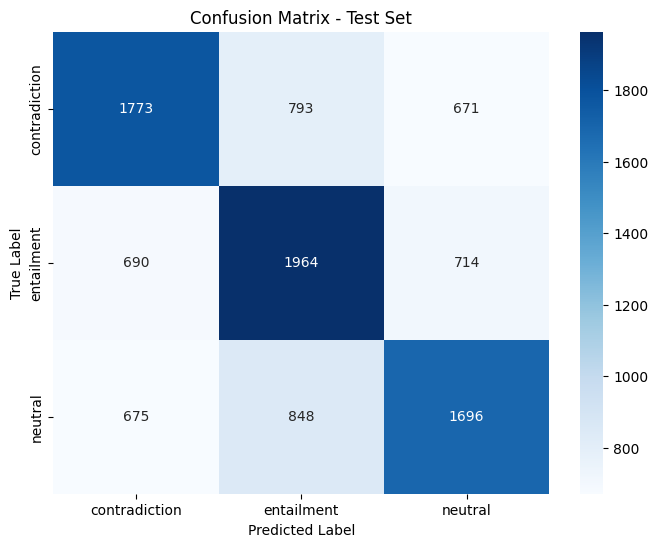


=== ROC Curves (One-vs-All) ===


/tmp/ipython-input-953029915.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


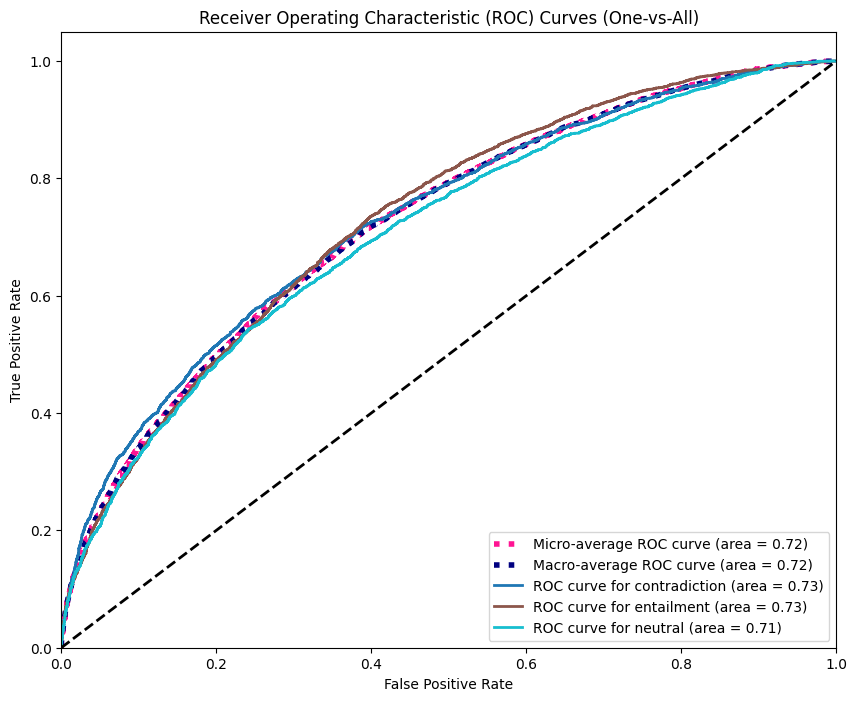

Starting hyperparameter tuning for lstm model...
Number of hyperparameter combinations: 6

Validating these parameters: {'hidden_dim': 256, 'lr': 0.01}
  Validation F1-score: 0.3742
  Found new best parameters!

Validating these parameters: {'hidden_dim': 256, 'lr': 0.001}
  Validation F1-score: 0.6562
  Found new best parameters!

Validating these parameters: {'hidden_dim': 512, 'lr': 0.01}
  Validation F1-score: 0.3276

Validating these parameters: {'hidden_dim': 512, 'lr': 0.001}
  Validation F1-score: 0.6641
  Found new best parameters!

Validating these parameters: {'hidden_dim': 1024, 'lr': 0.01}
  Validation F1-score: 0.1649

Validating these parameters: {'hidden_dim': 1024, 'lr': 0.001}
  Validation F1-score: 0.6790
  Found new best parameters!

Hyperparameter tuning finished.
Best validation F1-score: 0.6790
Best parameters: {'hidden_dim': 1024, 'lr': 0.001}

Best LSTM Parameters: {'hidden_dim': 1024, 'lr': 0.001}
Starting final training for 10 epochs...
=== Evaluation Metrics

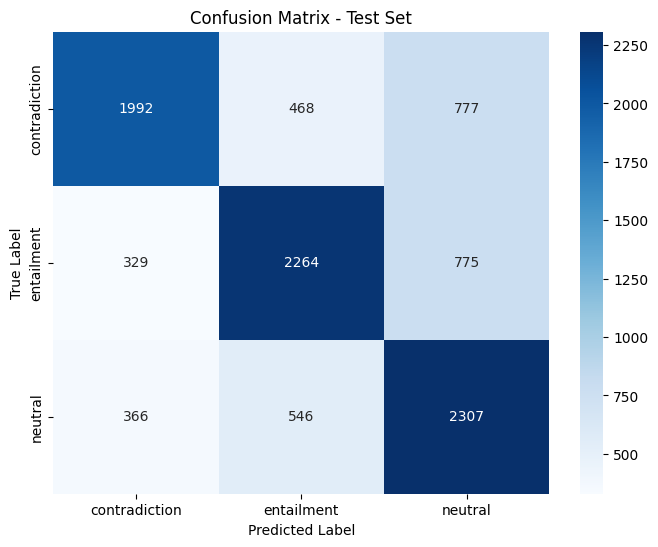


=== ROC Curves (One-vs-All) ===


/tmp/ipython-input-953029915.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


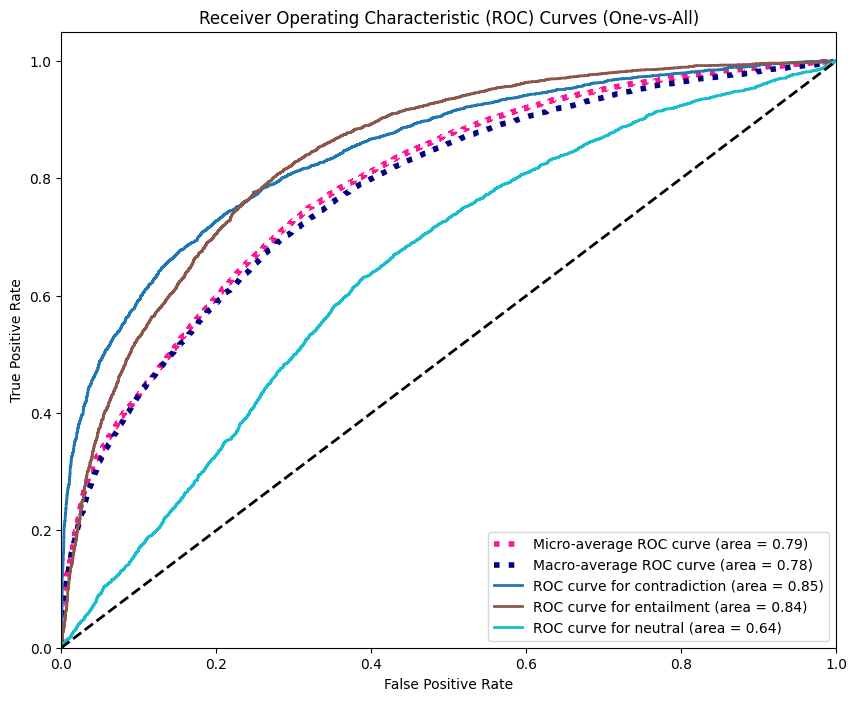

In [ ]:
#======================================================
# 16. ADDESTRAMENTO E VALUTAZIONE MODELLI PIU' AVANZATI
#======================================================

# EPOCHE DI ADDESTRAMENTO
EPOCHS = 10
n_classes = 3

# LOGISTIC REGRESSION SU BIGRAMMI:

# 1. FASE DI SELEZIONE DEGLI IPERPARAMETRI
n_features_lr = X_train_tensor_2.shape[1]

param_grid_lr = {'lr': [0.0005, 0.001]}
label_encoder_lr = label_encoder

best_lr_params = tune_model(
     'logistic_regression', LogisticRegressionModel, param_grid_lr,
     train_dataloader_lr_bi,
     val_dataloader_lr_bi,
     test_dataloader_lr_bi,
     device,
     criterion,
     label_encoder_lr,
     n_features=n_features_lr,
     n_classes=n_classes
 )
print("\nBest Logistic Regression Parameters:", best_lr_params)

#2. ADDESTRAMETO MIGLIOR MODELLO
lr_finale = LogisticRegressionModel(
    n_features=n_features_lr,
    n_classes=n_classes
    )
lr_finale.to(device)

final_optimizer_lr = Adam(lr_finale.parameters(), lr=best_lr_params['lr'])

# 3. Avvio addestramento
lr_addestrata = train_final_model(
     lr_finale,
     train_dataloader_lr_bi,
     val_dataloader_lr_bi,
     device,
     criterion,
     final_optimizer_lr,
     EPOCHS,
     model_type='logistic_regression'
)

# 4. Valutare il modello addestrato sul set di test.
evaluate_model(lr_addestrata, test_dataloader_lr_bi, device, label_encoder_lr, model_type = 'logistic_regression')


# LSTM:
VOCAB_SIZE = len(word_to_idx)
EMBEDDING_DIM = 300
label_encoder_lstm = label_encoder

embedding_matrix = glove_matrix
param_grid_lstm = {
     'hidden_dim': [256, 512, 1024],
     'lr': [0.01, 0.001]
 }

best_lstm_params = tune_model(
    'lstm', LSTMNLIModel, param_grid_lstm,
     train_dataloader_lstm,
     val_dataloader_lstm,
     test_dataloader_lstm,
     device,
     criterion,
     label_encoder_lstm,
     vocab_size=VOCAB_SIZE,
     embedding_dim=EMBEDDING_DIM,
     num_classes = n_classes,
     embedding_matrix=embedding_matrix
 )
print("\nBest LSTM Parameters:", best_lstm_params)

lstm_finale = LSTMNLIModel(
     vocab_size=VOCAB_SIZE,
     embedding_dim=EMBEDDING_DIM,
     hidden_dim=best_lstm_params['hidden_dim'],
     num_classes=n_classes,
     embedding_matrix=embedding_matrix)
lstm_finale.to(device)

final_optimizer_lstm = Adam(lstm_finale.parameters(), lr=best_lstm_params['lr'])

# ADDESTRAMENTO MIGLIOR MODELLO LSTM
lstm_addestrata = train_final_model(
     lstm_finale,
     train_dataloader_lstm,
     val_dataloader_lstm,
     device,
     criterion,
     final_optimizer_lstm,
     EPOCHS,
     model_type='lstm'
)

# VALUTAZIONE MODELLO
evaluate_model(lstm_addestrata, test_dataloader_lstm, device, label_encoder_lstm, model_type='lstm')


**Risultati Finali e Confronto tra i Modelli**

Questa sezione presenta i risultati conclusivi del nostro progetto, ottenuti al termine del processo di ottimizzazione e valutazione per entrambi i modelli implementati: la baseline di Regressione Logistica e il modello avanzato LSTM.

Modello Baseline: Regressione Logistica con TF-IDF

Il nostro primo modello, più semplice, è servito a stabilire un punto di riferimento. Il processo di tuning ha identificato come ottimale un learning rate di 0.001. Una volta addestrato con questa configurazione, il modello è stato valutato sul test set, ottenendo i seguenti risultati:

    Accuracy Finale: 55%

    F1-Score (Macro Avg): 0.55

Le performance, sebbene modeste, sono superiori alla soglia casuale (33.3%), confermando che il modello ha appreso alcuni pattern di base. La matrice di confusione mostra una certa difficoltà nel distinguere le classi, con una distribuzione degli errori relativamente uniforme.

Modello Avanzato: LSTM con Embedding GloVe

Per il nostro modello LSTM, la ricerca degli iperparametri è stata più estesa, esplorando diverse dimensioni per lo stato nascosto e diversi learning rate. La configurazione migliore è emersa con un learning rate di 0.001 e una dimensione dello stato nascosto 1024, ottenendo un F1-score di validazione di 0.67.

La valutazione finale di questo modello ottimizzato sul test set ha confermato la sua superiorità:

    Accuracy Finale: 67%

    F1-Score (Macro Avg): 0.67

Il modello LSTM ha ottenuto un incremento di accuratezza di 12 punti percentuali rispetto alla baseline. Come visibile dalla matrice di confusione, il modello è più abile nel distinguere le tre classi, in particolare entailment e neutral, dimostrando una comprensione più profonda delle relazioni logiche. Le curve ROC confermano una buona capacità di separazione per tutte le classi.

**Conclusioni**

Il confronto tra i due modelli è inequivocabile. L'architettura LSTM, grazie alla sua capacità di processare le frasi come sequenze e di sfruttare la ricchezza semantica degli embedding pre-addestrati, supera nettamente l'approccio basato su TF-IDF.

Mentre la Regressione Logistica offre una soluzione rapida e un benchmark utile, è il modello LSTM che si dimostra in grado di apprendere le complesse relazioni logiche e contestuali necessarie per risolvere il task di Natural Language Inference. Il modello finale con hidden_dim=1024 e lr=0.001 rappresenta la soluzione più performante sviluppata in questo progetto.

**Sviluppi Futuri**

Un primo potenziamento consisterebbe nello sfruttare la struttura sintattica intrinseca del linguaggio. Il dataset SNLI fornisce il testo già corredato di alberi di parsing (parse tree), una ricchezza di informazioni che il nostro modello LSTM, processando il testo in modo lineare, non è in grado di utilizzare. L'adozione di un'architettura Tree-LSTM, una variante che opera direttamente su strutture ad albero, permetterebbe al modello di propagare l'informazione seguendo le dipendenze grammaticali.  Questo approccio, più fedele alla natura gerarchica del linguaggio, potrebbe catturare le relazioni composizionali del significato in modo più accurato e portare a un sensibile miglioramento delle performance.

Un'altra via, più legata all'ottimizzazione del training, sarebbe quella di estendere il numero di epoche di addestramento. I nostri modelli, specialmente l'LSTM, sono stati addestrati per un tempo limitato. Concedere più tempo per l'apprendimento potrebbe permettere al modello di convergere verso una soluzione migliore. Per evitare il rischio di overfitting, questo approccio andrebbe abbinato a una tecnica di early stopping, che monitora le performance sul set di validazione e interrompe l'addestramento non appena si smette di osservare un miglioramento, garantendo così di raggiungere il punto ottimale.

Infine, per un salto qualitativo decisivo, si potrebbe passare a un'architettura basata su Transformer, come BERT. Questo modello supera i limiti dell'LSTM grazie a due innovazioni chiave. In primo luogo, genera embedding contestuali, per cui la rappresentazione di una parola cambia a seconda del contesto in cui si trova. In secondo luogo, il suo meccanismo di attenzione gli permette di pesare l'importanza di ogni parola in relazione a tutte le altre nella frase, catturando il contesto in modo bidirezionale e molto più efficace. L'approccio consisterebbe nel fine-tuning di un modello BERT pre-addestrato, sfruttando la sua immensa conoscenza linguistica per adattarla al nostro task specifico, con il potenziale di raggiungere performance notevolmente superiori.